# Experiment: Rulkov Map 0321 Whitened Koopman Chain

本 notebook 面向两群体 Rulkov map，按照四种同步状态分别完成白化 Koopman 分析，并在最后汇总比较。

## Part 1. 共同参数配置

### Block 1. 环境导入与统一风格

这一部分负责导入实验所需的工具函数，并统一绘图风格，保证四种状态的结果可以直接比较。

In [14]:

import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pysindy as ps

from tools.tools import (
    compute_transition_covariances,
    fit_data_koopman_operator,
    get_positive_contributions,
    compute_entropy,
    init_artifacts,
    analyze_kbar_metrics,
    build_macro_from_kbar,
    print_summary,
    generate_two_population_neuron_data,
    plot_neuron_analysis_combo,
    extract_state_matrix_from_rulkov_data,
    build_map_comparison_table,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei',
    'Noto Sans CJK SC',
    'Source Han Sans SC',
    'Arial Unicode MS',
    'DejaVu Sans',
]

HEATMAP_CMAP = 'vlag'


def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if idx % step == 0 else '' for idx, label in enumerate(labels)]


def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 5), label_step=1, cmap=HEATMAP_CMAP):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=sparse_labels(col_labels, label_step),
        yticklabels=sparse_labels(row_labels, label_step),
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
    plt.tight_layout()
    plt.show()


def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


### Block 2. 全局参数配置

这里统一设置公共分析参数，以及四种 Rulkov 状态的数据生成参数。

In [15]:

config = {
    'experiment_name': 'exp_map_0321',
    'observable_mode': 'identity',
    'include_x': True,
    'include_y': True,
    'use_transient': True,
    'burn_in_steps': 0,
    'sample_stride': 1,
    'lag_steps': 1,
    'alpha': 1.0,
    'eps': 1e-10,
    'ridge': 1e-10,
    'rank': None,
    'rank_candidates': [1, 2, 3, 4, 5, 6, 8, 10],
    'selected_micro_indices': [0, 1, 200, 201],
    'heatmap_label_step': 20,
    'top_k_features_to_show': 6,
    'states': {
        'CS': {
            'label': 'Complete Synchronization (CS)',
            'n_a': 100,
            'n_b': 100,
            'alpha_a': 4.6,
            'alpha_b': 4.6,
            'sigma_a': 0.225,
            'sigma_b': 0.225,
            'mu': 0.001,
            'gamma': 0.005,
            'epsilon': 0.002,
            'T': 5000,
            'transients': 3000,
            'seed': 101,
            'x0_a': -1.0,
            'x0_b': -1.0,
            'y0_a': -3.5,
            'y0_b': -3.5,
        },
        'GS': {
            'label': 'Generalized Synchronization (GS)',
            'n_a': 100,
            'n_b': 100,
            'alpha_a': 4.6,
            'alpha_b': 4.6,
            'sigma_a': 0.225,
            'sigma_b': 0.225,
            'mu': 0.001,
            'gamma': 0.06,
            'epsilon': 0.02,
            'T': 5000,
            'transients': 1000,
            'seed': 100,
            'x0_a': -1.0,
            'x0_b': -1.2,
            'y0_a': -3.5,
            'y0_b': -3.7,
        },
        'Q': {
            'label': 'Chimera State (Q)',
            'n_a': 100,
            'n_b': 100,
            'alpha_a': 4.6,
            'alpha_b': 4.6,
            'sigma_a': 0.225,
            'sigma_b': 0.225,
            'mu': 0.001,
            'gamma': 0.005,
            'epsilon': 0.002,
            'T': 5000,
            'transients': 3000,
            'seed': 103,
            'x0_a': -1.0,
            'x0_b': None,
            'y0_a': -3.5,
            'y0_b': None,
        },
        'D': {
            'label': 'Desynchronization (D)',
            'n_a': 100,
            'n_b': 100,
            'alpha_a': 4.6,
            'alpha_b': 4.6,
            'sigma_a': 0.225,
            'sigma_b': 0.225,
            'mu': 0.001,
            'gamma': 0.005,
            'epsilon': 0.002,
            'T': 5000,
            'transients': 3000,
            'seed': 155,
            'x0_a': None,
            'x0_b': None,
            'y0_a': None,
            'y0_b': None,
        },
    },
}

state_order = ['CS', 'GS', 'Q', 'D']
artifacts = init_artifacts(config)
config


{'experiment_name': 'exp_map_0321',
 'observable_mode': 'identity',
 'include_x': True,
 'include_y': True,
 'use_transient': True,
 'burn_in_steps': 0,
 'sample_stride': 1,
 'lag_steps': 1,
 'alpha': 1.0,
 'eps': 1e-10,
 'ridge': 1e-10,
 'rank': None,
 'rank_candidates': [1, 2, 3, 4, 5, 6, 8, 10],
 'selected_micro_indices': [0, 1, 200, 201],
 'heatmap_label_step': 20,
 'top_k_features_to_show': 6,
 'states': {'CS': {'label': 'Complete Synchronization (CS)',
   'n_a': 100,
   'n_b': 100,
   'alpha_a': 4.6,
   'alpha_b': 4.6,
   'sigma_a': 0.225,
   'sigma_b': 0.225,
   'mu': 0.001,
   'gamma': 0.005,
   'epsilon': 0.002,
   'T': 5000,
   'transients': 3000,
   'seed': 101,
   'x0_a': -1.0,
   'x0_b': -1.0,
   'y0_a': -3.5,
   'y0_b': -3.5},
  'GS': {'label': 'Generalized Synchronization (GS)',
   'n_a': 100,
   'n_b': 100,
   'alpha_a': 4.6,
   'alpha_b': 4.6,
   'sigma_a': 0.225,
   'sigma_b': 0.225,
   'mu': 0.001,
   'gamma': 0.06,
   'epsilon': 0.02,
   'T': 5000,
   'transients': 

## Part 2. 完全同步 CS

这一部分完整展示实验二在 Rulkov map 上的分析链条：
数据生成 -> 状态矩阵提取 -> lift -> 转移协方差 -> $K_{\mathrm{raw}}$ 与 $\bar K$ -> 奇异值谱与 EC -> 主总分与宏观效率增益 -> 宏观变量。

### Block 3. 数据生成：完全同步 CS

先生成完全同步情形下的两群体 Rulkov 数据，并检查同步指标是否与目标状态一致。

State key: CS
State label: Complete Synchronization (CS)
Raw data shape: (2000, 400)
State dimension: 400
Sync metrics: {'R_a': np.float64(1.8314516569972737e-16), 'R_b': np.float64(1.8314516569972737e-16), 'R_t': np.float64(1.5442508383145536e-16), 'R_delta': np.float64(0.0), 'sync_state': 'Complete Synchronization 完全同步(CS)'}


,state,sync_state,R_a,R_b,R_t,R_delta
0,CS,Complete Synchronization 完全同步(CS),1.831452e-16,1.831452e-16,1.544251e-16,0.0


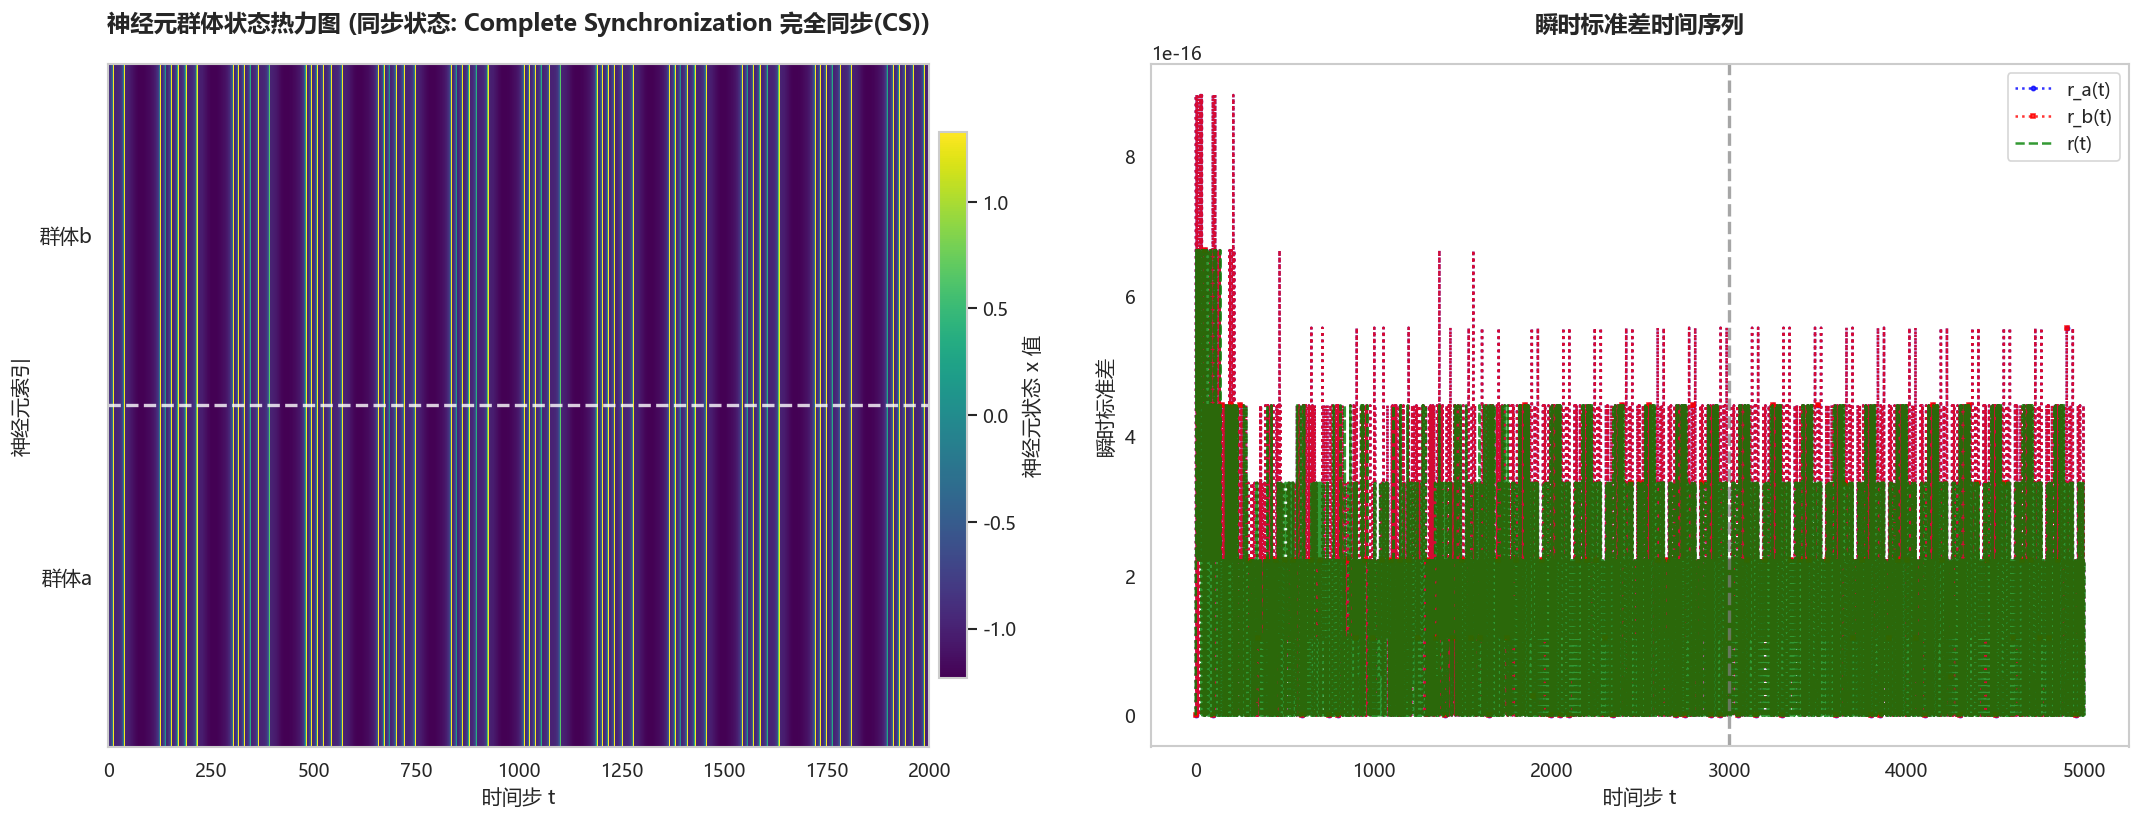

In [16]:
state_key_CS = 'CS'
state_cfg_CS = config['states'][state_key_CS]
state_args_CS = {k: v for k, v in state_cfg_CS.items() if k != 'label'}

print('State key:', state_key_CS)
print('State label:', state_cfg_CS['label'])

data_CS = generate_two_population_neuron_data(**state_args_CS)
raw_pack_CS = extract_state_matrix_from_rulkov_data(
    data_CS,
    include_x=config['include_x'],
    include_y=config['include_y'],
    use_transient=config['use_transient'],
)

x_data_raw_CS = raw_pack_CS['x_data_raw']
state_names_raw_CS = raw_pack_CS['state_names']
group_labels_CS = raw_pack_CS['group_labels']
t_data_raw_CS = raw_pack_CS['time_data']
sync_metrics_CS = raw_pack_CS['sync_metrics']

artifacts['CS'] = {'data': data_CS, 'raw_pack': raw_pack_CS}

print('Raw data shape:', x_data_raw_CS.shape)
print('State dimension:', x_data_raw_CS.shape[1])
print('Sync metrics:', sync_metrics_CS)

display(pd.DataFrame([{
    'state': state_key_CS,
    'sync_state': sync_metrics_CS.get('sync_state'),
    'R_a': sync_metrics_CS.get('R_a'),
    'R_b': sync_metrics_CS.get('R_b'),
    'R_t': sync_metrics_CS.get('R_t'),
    'R_delta': sync_metrics_CS.get('R_delta'),
}]))

plot_neuron_analysis_combo(data_CS, figsize=(18, 7))


### Block 4. 数据整理：统一输入矩阵

将 Rulkov 原始字典整理成统一轨道矩阵，并准备后续拟合所需的时间步长与索引设置。

In [17]:

burn_in_steps_CS = config['burn_in_steps']
sample_stride_CS = config['sample_stride']

x_data_fit_CS = x_data_raw_CS[burn_in_steps_CS::sample_stride_CS].copy()
t_data_fit_CS = t_data_raw_CS[burn_in_steps_CS::sample_stride_CS].copy()
state_names_fit_CS = state_names_raw_CS.copy()
dt_fit_CS = 1 * sample_stride_CS
tau_CS = config['lag_steps'] * dt_fit_CS
selected_micro_indices_CS = [idx for idx in config['selected_micro_indices'] if idx < x_data_raw_CS.shape[1]]

print('Burn-in steps removed:', burn_in_steps_CS)
print('Sample stride:', sample_stride_CS)
print('Prepared data shape:', x_data_fit_CS.shape)
print('tau =', tau_CS)


Burn-in steps removed: 0
Sample stride: 1
Prepared data shape: (2000, 400)
tau = 1


### Block 5. 观测函数与 lift

这里先采用恒等观测，保证四种状态之间的比较主要反映动力学差异，而不是观测函数差异。

In [18]:

ide_CS = ps.IdentityLibrary()
library_CS = ide_CS
library_CS.fit(x_data_fit_CS)
x_data_lift_CS = library_CS.transform(x_data_fit_CS)
raw_names_CS = library_CS.get_feature_names(input_features=state_names_fit_CS)
x_data_lift_centered_CS = x_data_lift_CS - np.mean(x_data_lift_CS, axis=0, keepdims=True)
x_data_lift_CS = x_data_lift_centered_CS

print('Observable mode:', config['observable_mode'])
print('Input shape:', x_data_fit_CS.shape)
print('Lifted shape:', x_data_lift_CS.shape)
print('First 12 feature names:', raw_names_CS[:12])


Observable mode: identity
Input shape: (2000, 400)
Lifted shape: (2000, 400)
First 12 feature names: ['x_a1', 'y_a1', 'x_a2', 'y_a2', 'x_a3', 'y_a3', 'x_a4', 'y_a4', 'x_a5', 'y_a5', 'x_a6', 'y_a6']


### Block 6. 计算 $C_{00}$、$C_{01}$、$C_{11}$

通过时滞配对样本构造转移协方差矩阵，为后续白化 Koopman 算子做准备。

In [19]:

transition_stats_CS = compute_transition_covariances(
    [x_data_lift_CS],
    library=None,
    weights='uniform',
    lag_steps=config['lag_steps'],
)

C00_CS = transition_stats_CS['C00']
C01_CS = transition_stats_CS['C01']
C11_CS = transition_stats_CS['C11']
X_pairs_CS = transition_stats_CS['X']
Y_pairs_CS = transition_stats_CS['Y']

print(f'lag_steps = {config["lag_steps"]}, tau = {tau_CS:.6f}')
print('Pair count:', X_pairs_CS.shape[0])
print('C00 shape:', C00_CS.shape)
print('C01 shape:', C01_CS.shape)
print('C11 shape:', C11_CS.shape)
print('cond(C00):', np.linalg.cond(C00_CS))
print('cond(C11):', np.linalg.cond(C11_CS))


lag_steps = 1, tau = 1.000000
Pair count: 1999
C00 shape: (400, 400)
C01 shape: (400, 400)
C11 shape: (400, 400)
cond(C00): 8.934634885832388e+252
cond(C11): 1.6674179755023404e+252


### Block 7. 构造 $K_{\mathrm{raw}}$ 与 $\bar K$

先得到原始 Koopman 近似，再做白化，后续谱分析主要基于 $\bar K$。

K_raw shape: (400, 400)
K_bar shape: (400, 400)
||K_bar - K_bar_from_A||_F = 2.5464677613468765
sigma_max(K_bar): 0.9999999303080148


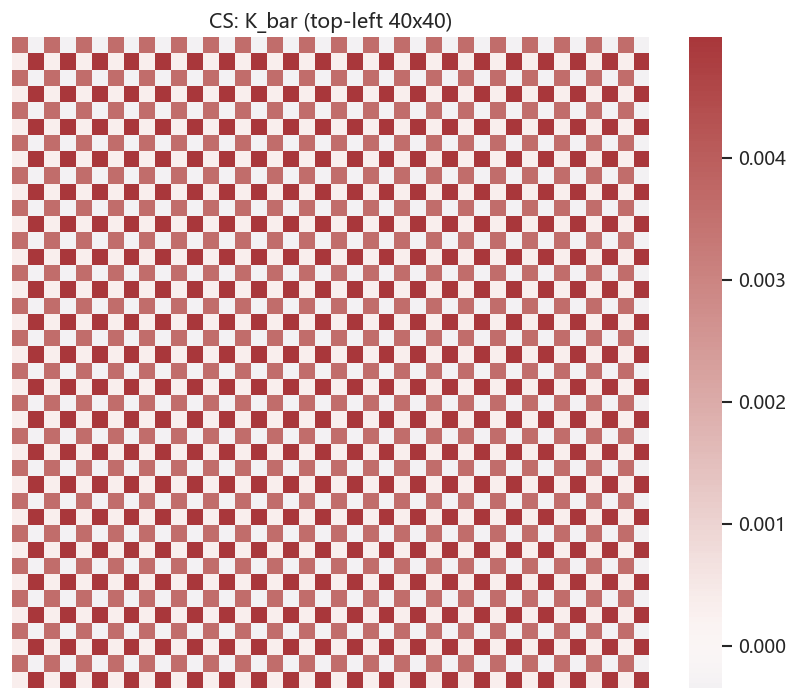

In [20]:

koop_fit_CS = fit_data_koopman_operator(
    [x_data_lift_CS],
    library=None,
    weights='uniform',
    eps=config['eps'],
    ridge=config['ridge'],
    lag_steps=config['lag_steps'],
)

K_raw_CS = koop_fit_CS['A']
K_bar_CS = koop_fit_CS['K_bar']
K_bar_from_A_CS = koop_fit_CS['K_bar_from_A']
C00_inv_sqrt_CS = koop_fit_CS['C00_inv_sqrt']
C11_inv_sqrt_CS = koop_fit_CS['C11_inv_sqrt']

print('K_raw shape:', K_raw_CS.shape)
print('K_bar shape:', K_bar_CS.shape)
print('||K_bar - K_bar_from_A||_F =', np.linalg.norm(K_bar_CS - K_bar_from_A_CS))
print('sigma_max(K_bar):', np.linalg.svd(K_bar_CS, compute_uv=False)[0])

plot_matrix_heatmap(K_bar_CS[:40, :40], 'CS: K_bar (top-left 40x40)', figsize=(7, 6), label_step=5)


### Block 8. 奇异值谱分析与 EC 指标

对 $K_{\mathrm{raw}}$ 和 $\bar K$ 做奇异值分解，其中 EC 只基于 $\bar K$ 的奇异值谱计算。

Top 10 singular values of K_bar: [9.99999930e-01 7.23005627e-01 4.42923750e-05 3.73182573e-05
 3.61514543e-05 2.64012293e-05 4.23941603e-08 1.58761175e-08
 1.31641967e-08 1.16370067e-08]
Top 10 singular values of K_raw: [5.44234235e+00 1.32892185e-01 3.12625898e-05 1.17116258e-05
 8.29289245e-06 5.97538414e-06 2.12480574e-08 8.17347050e-09
 6.22315651e-09 4.63646115e-09]
EC: 6.375798523121294


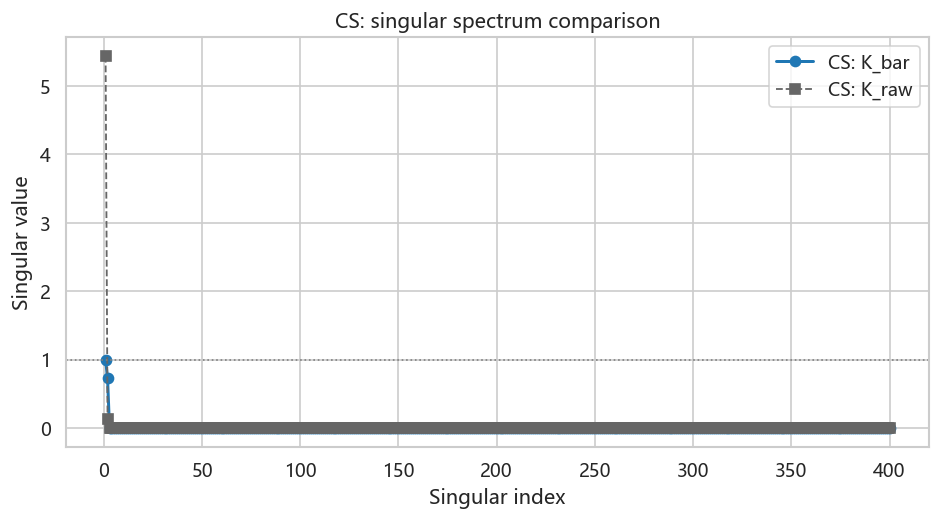

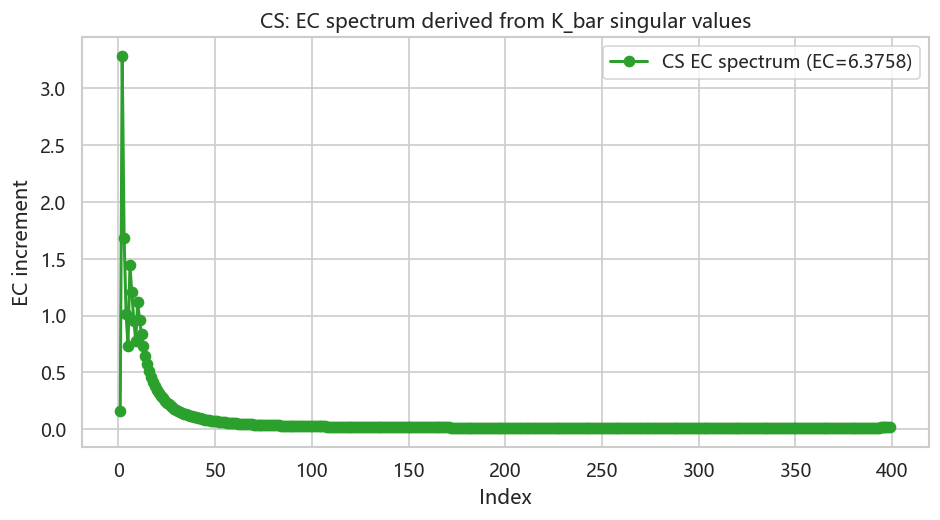

In [21]:

U_raw_CS, S_raw_CS, Vt_raw_CS = np.linalg.svd(K_raw_CS, full_matrices=False)
metrics_CS = analyze_kbar_metrics(K_bar_CS, alpha=config['alpha'], eps=config['eps'])

U_bar_CS = metrics_CS['U']
S_bar_CS = metrics_CS['S']
Vt_bar_CS = metrics_CS['Vt']

diff_CS = get_positive_contributions(S_bar_CS)
EC_CS = compute_entropy(diff_CS)

print('Top 10 singular values of K_bar:', S_bar_CS[:10])
print('Top 10 singular values of K_raw:', S_raw_CS[:10])
print('EC:', EC_CS)

fig, ax = plt.subplots(figsize=(8, 4.5))
idx_bar_CS = np.arange(1, len(S_bar_CS) + 1)
idx_raw_CS = np.arange(1, len(S_raw_CS) + 1)
ax.plot(idx_bar_CS, S_bar_CS, marker='o', linewidth=1.8, label='CS: K_bar', color='tab:blue')
ax.plot(idx_raw_CS, S_raw_CS, marker='s', linewidth=1.1, linestyle='--', label='CS: K_raw', color='0.4')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('CS: singular spectrum comparison')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(diff_CS) + 1), diff_CS, marker='o', linewidth=1.8, color='tab:green', label=f'CS EC spectrum (EC={EC_CS:.4f})')
ax.set_xlabel('Index')
ax.set_ylabel('EC increment')
ax.set_title('CS: EC spectrum derived from K_bar singular values')
ax.legend()
plt.tight_layout()
plt.show()


### Block 9. 计算 $D_K$、$N_K$ 与主总分 $\mathcal G_\alpha^K$

这一块提取白化 Koopman 诱导的核心矩阵与主总分，用于比较四种同步状态的整体信息组织强度。

log pdet(D_K): 16.525721244284817
log pdet(N_K): -1412.4360150180441
G_alpha^K: -348.97757344343984


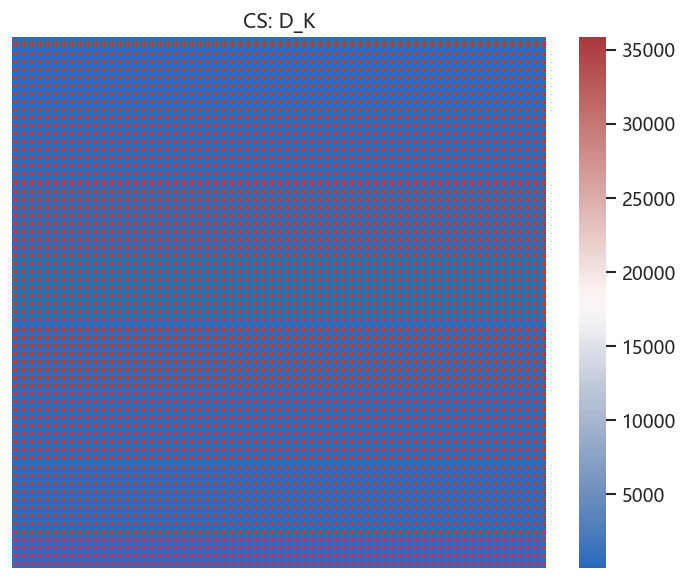

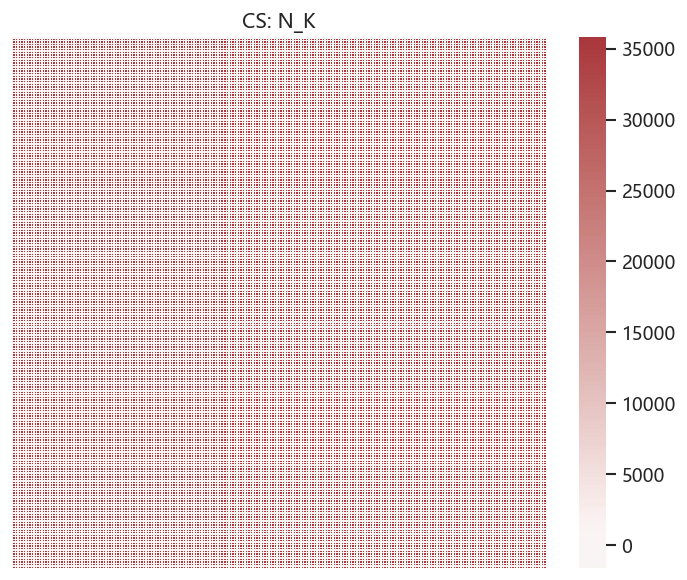

In [22]:

D_K_CS = metrics_CS['D_K']
N_K_CS = metrics_CS['N_K']
G_alpha_K_CS = metrics_CS['G_alpha_K']

print('log pdet(D_K):', metrics_CS['log_pdet_D_K'])
print('log pdet(N_K):', metrics_CS['log_pdet_N_K'])
print('G_alpha^K:', G_alpha_K_CS)

plot_matrix_heatmap(D_K_CS, 'CS: D_K', center=None, figsize=(6, 5), cmap=HEATMAP_CMAP)
plot_matrix_heatmap(N_K_CS, 'CS: N_K', center=0.0, figsize=(6, 5), cmap=HEATMAP_CMAP)


### Block 10. 截断维数 $r$、单通道得分与宏观效率增益

对不同截断维数计算宏观效率增益，并据此选择该状态下的代表性宏观维数。

Channel scores g_i^K(alpha): [ 7.89301665  0.2076748  -5.01234901 -5.09801394 -5.11389669 -5.27104999
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273 -5.75646273
 -5.75646273 -5.756462

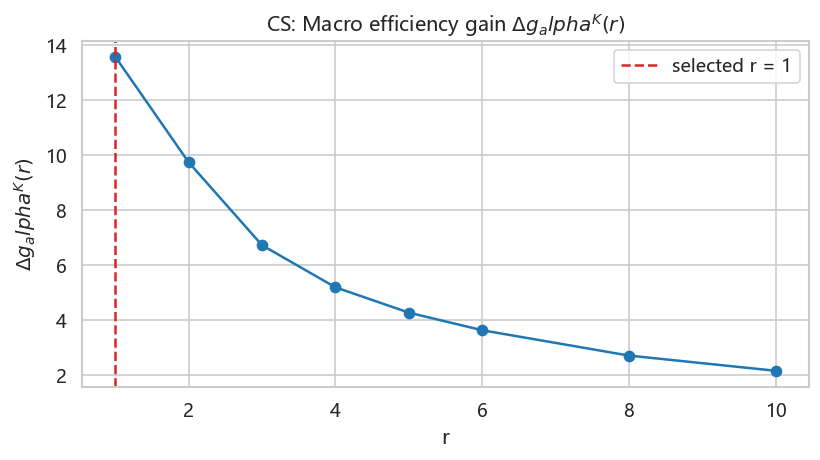

In [23]:

rho2_CS = np.clip(S_bar_CS**2, config['eps'], 1.0 - config['eps'])
g_i_CS = (0.5 - config['alpha'] / 4.0) * np.log(rho2_CS / (1.0 - rho2_CS)) + (config['alpha'] / 4.0) * np.log(1.0 / (1.0 - rho2_CS))
rank_candidates_CS = [r for r in config['rank_candidates'] if 1 <= r <= len(g_i_CS)]
delta_g_by_r_CS = {r: float(np.mean(g_i_CS[:r]) - np.mean(g_i_CS)) for r in rank_candidates_CS}
selected_r_CS = int(config['rank']) if config['rank'] is not None else int(max(delta_g_by_r_CS, key=delta_g_by_r_CS.get))

print('Channel scores g_i^K(alpha):', g_i_CS)
print('Delta g by r:', delta_g_by_r_CS)
print('Selected r:', selected_r_CS)
print('Macro efficiency gain CE:', delta_g_by_r_CS[selected_r_CS])

plt.figure(figsize=(7, 4))
plt.plot(list(delta_g_by_r_CS.keys()), list(delta_g_by_r_CS.values()), marker='o', color='tab:blue')
plt.axvline(selected_r_CS, color='tab:red', linestyle='--', label=f'selected r = {selected_r_CS}')
plt.title(r'CS: Macro efficiency gain $\Delta g_alpha^K(r)$')
plt.xlabel('r')
plt.ylabel(r'$\Delta g_alpha^K(r)$')
plt.legend()
plt.tight_layout()
plt.show()


### Block 11. 左奇异向量结构可视化

观察主导左奇异向量在不同微观变量上的权重分布，帮助理解宏观模式由哪些通道主导。

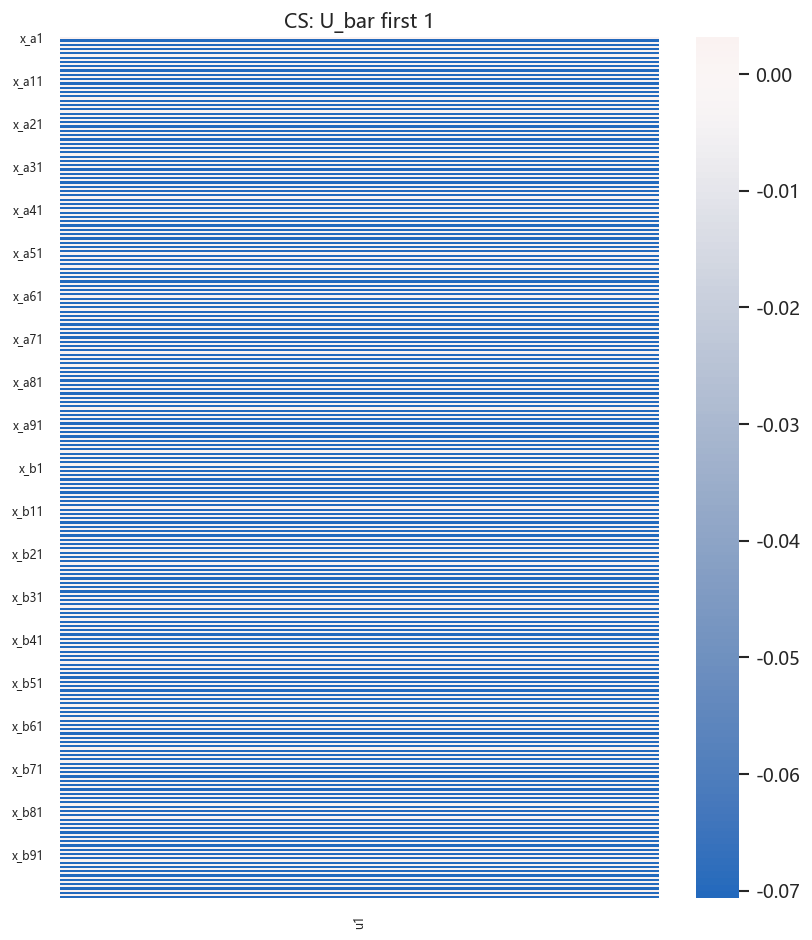

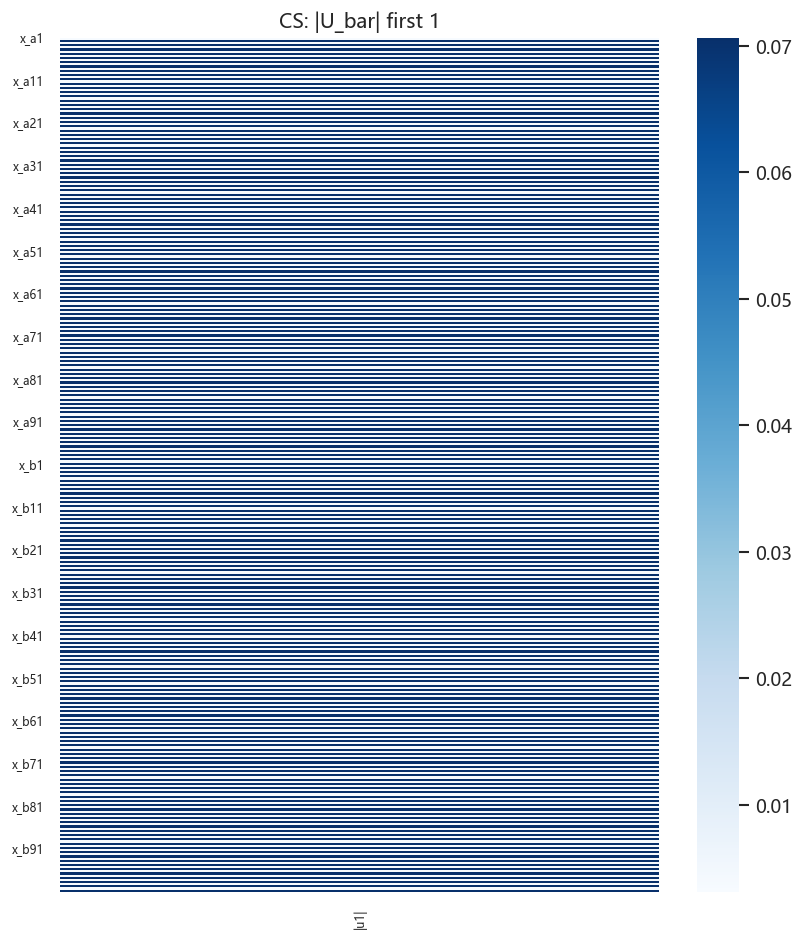

In [24]:

plot_matrix_heatmap(U_bar_CS[:, :selected_r_CS], f'CS: U_bar first {selected_r_CS}', row_labels=raw_names_CS, col_labels=[f'u{i+1}' for i in range(selected_r_CS)], figsize=(7, 8), label_step=config['heatmap_label_step'])
plot_matrix_heatmap(np.abs(U_bar_CS[:, :selected_r_CS]), f'CS: |U_bar| first {selected_r_CS}', row_labels=raw_names_CS, col_labels=[f'|u{i+1}|' for i in range(selected_r_CS)], center=None, figsize=(7, 8), label_step=config['heatmap_label_step'], cmap='Blues')


### Block 12. 构造粗粒化函数与宏观变量

根据前面选择的截断维数构造宏观变量，并列出每个宏观分量的主导微观特征。

In [25]:

macro_CS = build_macro_from_kbar(
    U=U_bar_CS,
    S=S_bar_CS,
    Vt=Vt_bar_CS,
    C00_inv_sqrt=C00_inv_sqrt_CS,
    X=X_pairs_CS,
    r=selected_r_CS,
    feature_names=raw_names_CS,
    Y=Y_pairs_CS,
    C11_inv_sqrt=C11_inv_sqrt_CS,
    center=False,
)

print('Macro current shape:', macro_CS['z_current'].shape)
print('Macro future shape:', None if macro_CS['z_future'] is None else macro_CS['z_future'].shape)
print('Top features per macro component:')
for idx, items in enumerate(macro_CS['dominant_features'], start=1):
    print(f'  Component {idx}:')
    display(pd.DataFrame(items))


Macro current shape: (1999, 1)
Macro future shape: (1999, 1)
Top features per macro component:
  Component 1:


,feature,weight,abs_weight
0,y_a2,-0.615023,0.615023
1,y_a5,-0.615022,0.615022
2,y_a10,-0.615022,0.615022
3,y_a13,-0.615021,0.615021
4,y_a15,-0.615021,0.615021


### Block 13. 宏观数据与宏微观对比

展示宏观时间序列，并与若干微观通道做标准化后的可视化对比。

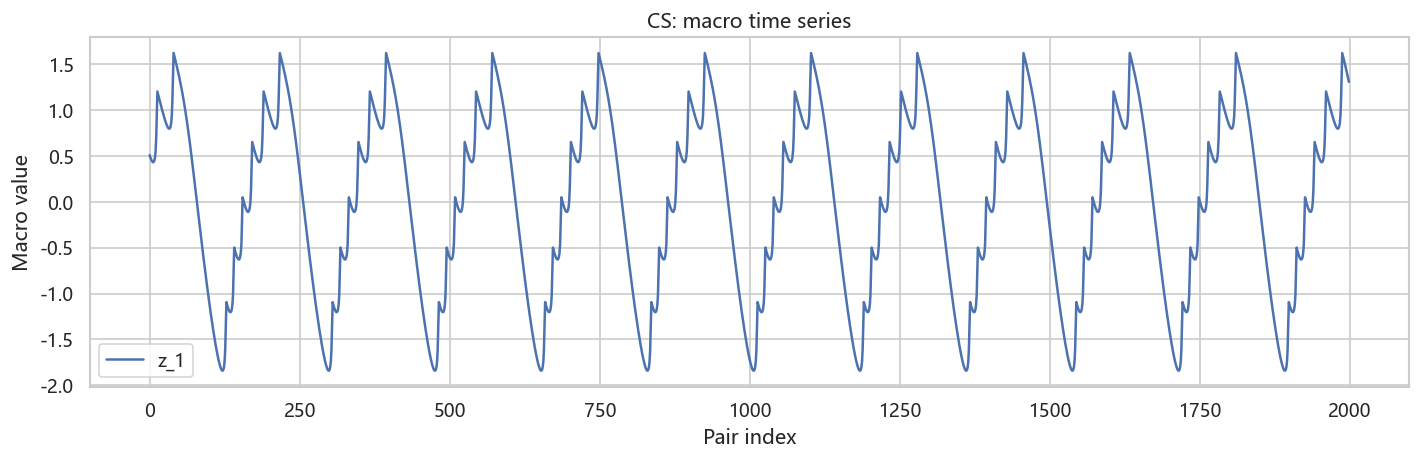

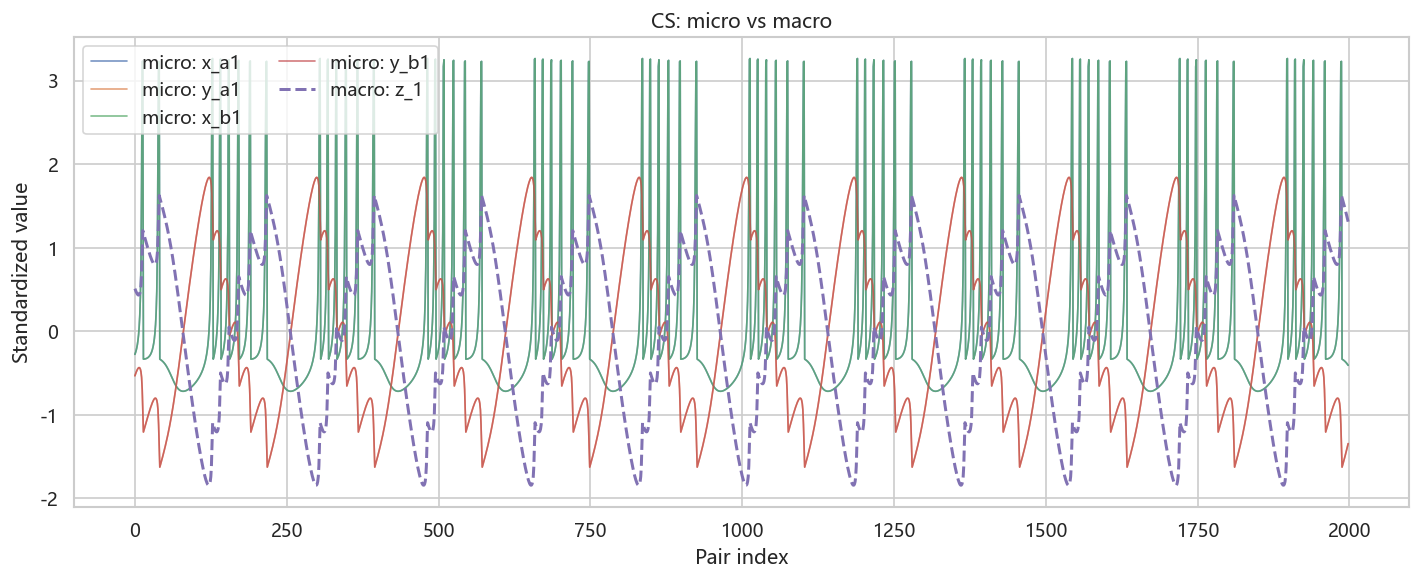

In [26]:

z_current_CS = macro_CS['z_current']
macro_names_CS = [f'z_{i+1}' for i in range(selected_r_CS)]

plt.figure(figsize=(12, 4))
for i in range(selected_r_CS):
    plt.plot(z_current_CS[:, i], linewidth=1.5, label=macro_names_CS[i])
plt.title('CS: macro time series')
plt.xlabel('Pair index')
plt.ylabel('Macro value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for idx in selected_micro_indices_CS:
    plt.plot(standardize_for_plot(X_pairs_CS[:, idx]), linewidth=1.0, alpha=0.75, label=f'micro: {raw_names_CS[idx]}')
for i in range(selected_r_CS):
    plt.plot(standardize_for_plot(z_current_CS[:, i]), linewidth=1.8, linestyle='--', label=f'macro: {macro_names_CS[i]}')
plt.title('CS: micro vs macro')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Block 14. 统一摘要输出

将这一状态下的关键指标整理为摘要，并保存为后续四状态比较所需的结果字典。

In [27]:

summary_dict_CS = {
    'experiment': {
        'name': config['experiment_name'],
        'state': state_key_CS,
        'label': state_cfg_CS['label'],
        'observable_mode': config['observable_mode'],
        'alpha': config['alpha'],
        'eps': config['eps'],
        'ridge': config['ridge'],
    },
    'data': {
        'raw_shape': x_data_raw_CS.shape,
        'prepared_shape': x_data_fit_CS.shape,
        'lifted_shape': x_data_lift_CS.shape,
        'pair_count': X_pairs_CS.shape[0],
        'tau': tau_CS,
        'lag_steps': config['lag_steps'],
    },
    'scores': {
        'sync_state': sync_metrics_CS.get('sync_state'),
        'R_a': sync_metrics_CS.get('R_a'),
        'R_b': sync_metrics_CS.get('R_b'),
        'R_t': sync_metrics_CS.get('R_t'),
        'R_delta': sync_metrics_CS.get('R_delta'),
        'G_alpha_K': G_alpha_K_CS,
        'EC': EC_CS,
        'selected_r': selected_r_CS,
        'delta_g_selected_r': delta_g_by_r_CS[selected_r_CS],
    },
}
print_summary(summary_dict_CS)

state_result_CS = {
    'state': state_key_CS,
    'label': state_cfg_CS['label'],
    'sync_metrics': sync_metrics_CS,
    'metrics': {
        'G_alpha_K': G_alpha_K_CS,
        'EC': EC_CS,
        'selected_r': selected_r_CS,
        'delta_g_selected_r': delta_g_by_r_CS[selected_r_CS],
        'effective_rank': metrics_CS['effective_rank'],
    },
    'singular_values': S_bar_CS,
    'singular_values_raw': S_raw_CS,
    'ec_spectrum': diff_CS,
    'summary': summary_dict_CS,
}


Summary

[experiment]
           item                         value
           name                  exp_map_0321
          state                            CS
          label Complete Synchronization (CS)
observable_mode                      identity
          alpha                           1.0
            eps                           0.0
          ridge                           0.0

[data]
          item       value
     raw_shape (2000, 400)
prepared_shape (2000, 400)
  lifted_shape (2000, 400)
    pair_count        1999
           tau           1
     lag_steps           1

[scores]
              item                             value
        sync_state Complete Synchronization 完全同步(CS)
               R_a                               0.0
               R_b                               0.0
               R_t                               0.0
           R_delta                               0.0
         G_alpha_K                       -348.977573
                EC              

## Part 3. 广义同步 GS

分析流程与 CS 相同，这里按相同块结构展示 GS 的结果。

### Block 3. 数据生成：GS 状态

生成该状态下的 Rulkov 数据，并先检查同步指标与状态标签。

State key: GS
State label: Generalized Synchronization (GS)
Raw data shape: (4000, 400)
Sync metrics: {'R_a': np.float64(2.28369948819529e-16), 'R_b': np.float64(2.3848512140794977e-16), 'R_t': np.float64(0.4517864064265471), 'R_delta': np.float64(0.9035728128530942), 'sync_state': 'Generalized Synchronization 广义同步 (GS)'}


,state,sync_state,R_a,R_b,R_t,R_delta
0,GS,Generalized Synchronization 广义同步 (GS),2.283699e-16,2.384851e-16,0.451786,0.903573


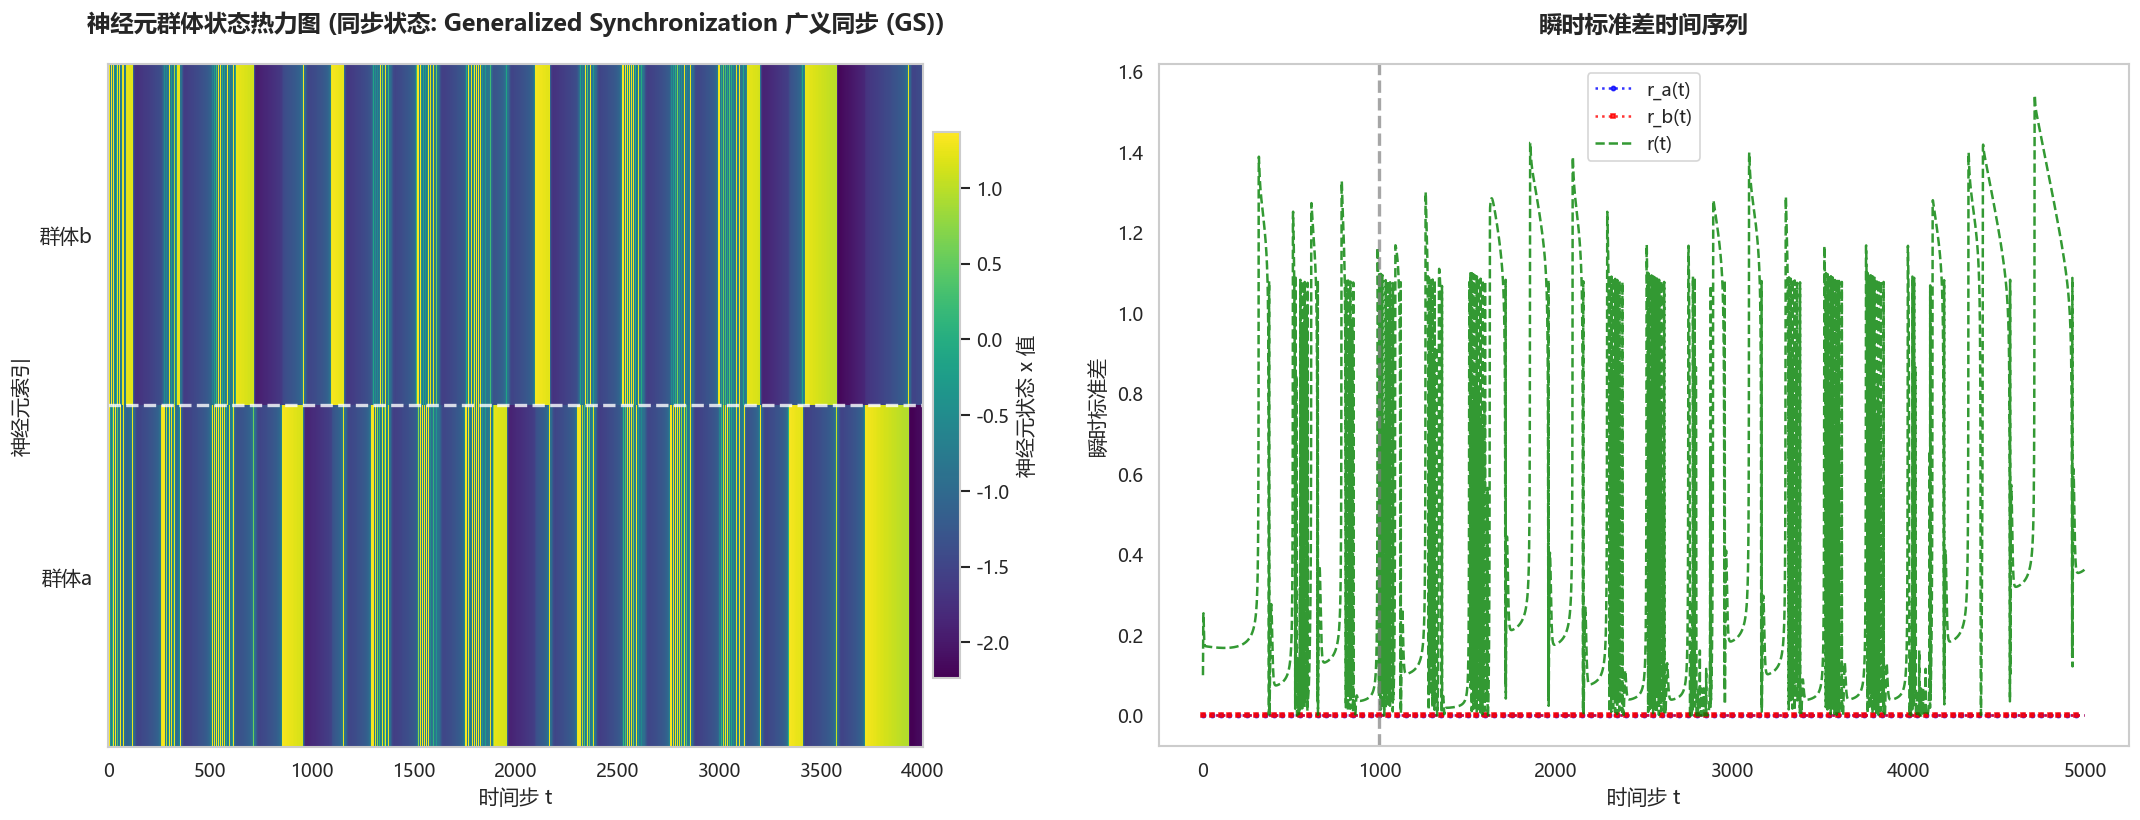

In [28]:

state_key_GS = 'GS'
state_cfg_GS = config['states'][state_key_GS]

state_args_GS = {k: v for k, v in state_cfg_GS.items() if k != 'label'}

data_GS = generate_two_population_neuron_data(**state_args_GS)
raw_pack_GS = extract_state_matrix_from_rulkov_data(
    data_GS,
    include_x=config['include_x'],
    include_y=config['include_y'],
    use_transient=config['use_transient'],
)

x_data_raw_GS = raw_pack_GS['x_data_raw']
state_names_raw_GS = raw_pack_GS['state_names']
t_data_raw_GS = raw_pack_GS['time_data']
sync_metrics_GS = raw_pack_GS['sync_metrics']
selected_micro_indices_GS = [idx for idx in config['selected_micro_indices'] if idx < x_data_raw_GS.shape[1]]

print('State key:', state_key_GS)
print('State label:', state_cfg_GS['label'])
print('Raw data shape:', x_data_raw_GS.shape)
print('Sync metrics:', sync_metrics_GS)
display(pd.DataFrame([{
    'state': state_key_GS,
    'sync_state': sync_metrics_GS.get('sync_state'),
    'R_a': sync_metrics_GS.get('R_a'),
    'R_b': sync_metrics_GS.get('R_b'),
    'R_t': sync_metrics_GS.get('R_t'),
    'R_delta': sync_metrics_GS.get('R_delta'),
}]))
plot_neuron_analysis_combo(data_GS, figsize=(18, 7))


### Block 4-7. 数据整理、lift 与白化 Koopman 构造

以下步骤与 CS 相同，这里简写说明，只保留结果输出与必要图表。

Prepared data shape: (4000, 400)
tau = 1
Pair count: 3999
cond(C00): 1.917621365454852e+238
cond(C11): 2.3039937015637512e+238
sigma_max(K_bar): 1.000000000011756


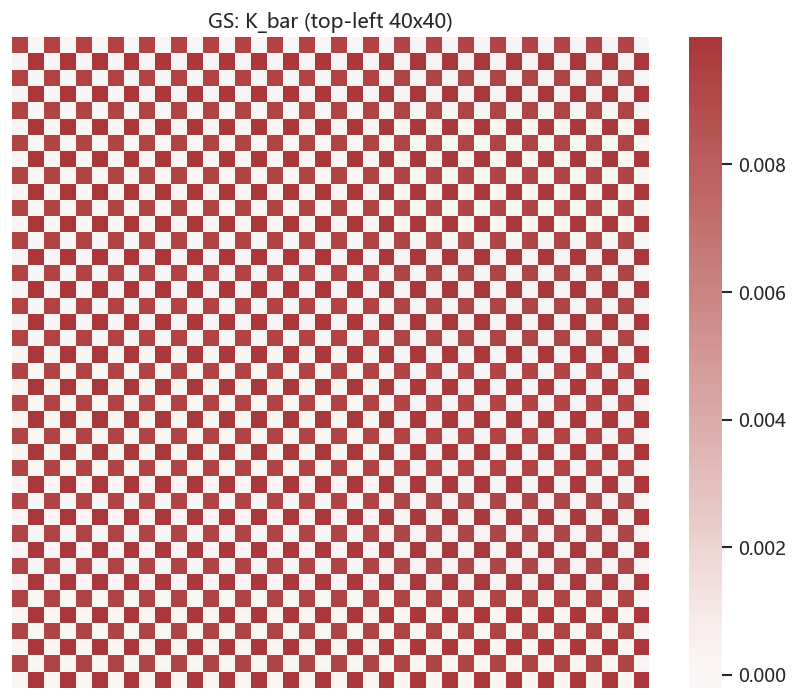

In [ ]:

x_data_fit_GS = x_data_raw_GS[config['burn_in_steps']::config['sample_stride']].copy()
t_data_fit_GS = t_data_raw_GS[config['burn_in_steps']::config['sample_stride']].copy()
state_names_fit_GS = state_names_raw_GS.copy()
dt_fit_GS = 1 * config['sample_stride']
tau_GS = config['lag_steps'] * dt_fit_GS

library_GS = ps.IdentityLibrary()
library_GS.fit(x_data_fit_GS)
x_data_lift_GS = library_GS.transform(x_data_fit_GS)
raw_names_GS = library_GS.get_feature_names(input_features=state_names_fit_GS)
x_data_lift_GS = x_data_lift_GS - np.mean(x_data_lift_GS, axis=0, keepdims=True)

transition_stats_GS = compute_transition_covariances(
    [x_data_lift_GS],
    library=None,
    weights='uniform',
    lag_steps=config['lag_steps'],
)
C00_GS = transition_stats_GS['C00']
C01_GS = transition_stats_GS['C01']
C11_GS = transition_stats_GS['C11']
X_pairs_GS = transition_stats_GS['X']
Y_pairs_GS = transition_stats_GS['Y']

koop_fit_GS = fit_data_koopman_operator(
    [x_data_lift_GS],
    library=None,
    weights='uniform',
    eps=config['eps'],
    ridge=config['ridge'],
    lag_steps=config['lag_steps'],
)
K_raw_GS = koop_fit_GS['A']
K_bar_GS = koop_fit_GS['K_bar']
C00_inv_sqrt_GS = koop_fit_GS['C00_inv_sqrt']
C11_inv_sqrt_GS = koop_fit_GS['C11_inv_sqrt']

print('Prepared data shape:', x_data_fit_GS.shape)
print('tau =', tau_GS)
print('Pair count:', X_pairs_GS.shape[0])
print('cond(C00):', np.linalg.cond(C00_GS))
print('cond(C11):', np.linalg.cond(C11_GS))
print('sigma_max(K_bar):', np.linalg.svd(K_bar_GS, compute_uv=False)[0])
plot_matrix_heatmap(K_bar_GS, 'GS: K_bar ', figsize=(7, 6), label_step=5)


### Block 8-10. 奇异值谱、EC 与宏观效率增益

以下指标与 CS 的定义完全相同，这里只展示该状态的谱结果和关键单值指标。

Top 10 singular values of K_bar: [1.00000000e+00 9.99999497e-01 9.33826680e-01 9.29479195e-01
 1.21203609e-04 8.11898547e-05 6.59686225e-05 4.81388355e-05
 5.52523450e-07 3.70396874e-07]
Top 10 singular values of K_raw: [1.12208157e+00 1.02022807e+00 9.16516981e-01 8.28723964e-01
 3.80885099e-05 3.23854393e-05 2.00087518e-05 1.73503649e-05
 4.76088301e-07 4.15342484e-07]
G_alpha^K: -65.67386412847962
EC: 6.577263091981384
Selected r: 1
Macro efficiency gain CE: 17.15083390903064


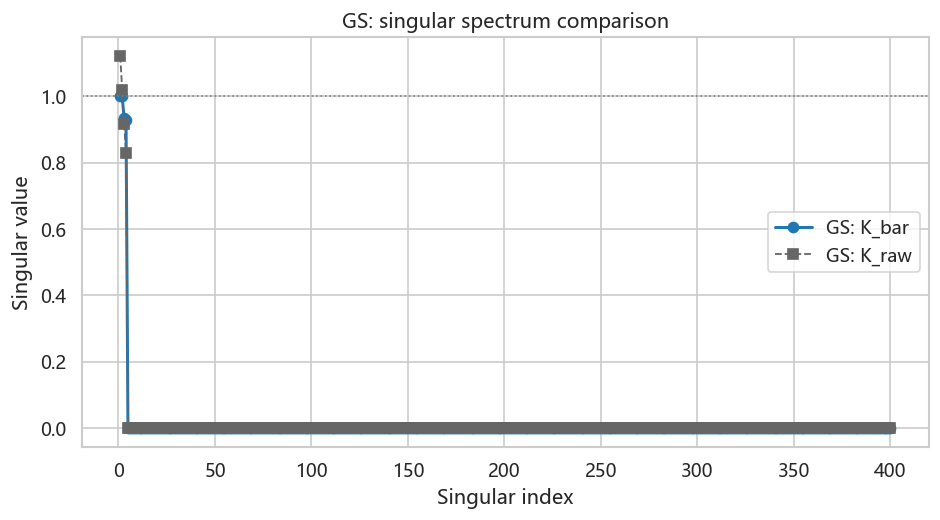

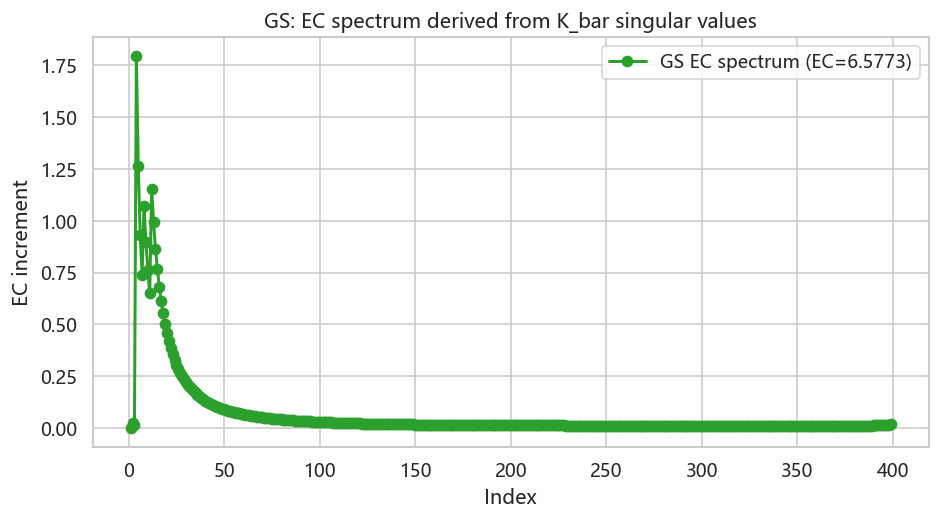

In [30]:

U_raw_GS, S_raw_GS, Vt_raw_GS = np.linalg.svd(K_raw_GS, full_matrices=False)
metrics_GS = analyze_kbar_metrics(K_bar_GS, alpha=config['alpha'], eps=config['eps'])
U_bar_GS = metrics_GS['U']
S_bar_GS = metrics_GS['S']
Vt_bar_GS = metrics_GS['Vt']
diff_GS = get_positive_contributions(S_bar_GS)
EC_GS = compute_entropy(diff_GS)

rho2_GS = np.clip(S_bar_GS**2, config['eps'], 1.0 - config['eps'])
g_i_GS = (0.5 - config['alpha'] / 4.0) * np.log(rho2_GS / (1.0 - rho2_GS)) + (config['alpha'] / 4.0) * np.log(1.0 / (1.0 - rho2_GS))
rank_candidates_GS = [r for r in config['rank_candidates'] if 1 <= r <= len(g_i_GS)]
delta_g_by_r_GS = {r: float(np.mean(g_i_GS[:r]) - np.mean(g_i_GS)) for r in rank_candidates_GS}
selected_r_GS = int(config['rank']) if config['rank'] is not None else int(max(delta_g_by_r_GS, key=delta_g_by_r_GS.get))

print('Top 10 singular values of K_bar:', S_bar_GS[:10])
print('Top 10 singular values of K_raw:', S_raw_GS[:10])
print('G_alpha^K:', metrics_GS['G_alpha_K'])
print('EC:', EC_GS)
print('Selected r:', selected_r_GS)
print('Macro efficiency gain CE:', delta_g_by_r_GS[selected_r_GS])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(S_bar_GS) + 1), S_bar_GS, marker='o', linewidth=1.8, label='GS: K_bar', color='tab:blue')
ax.plot(np.arange(1, len(S_raw_GS) + 1), S_raw_GS, marker='s', linewidth=1.1, linestyle='--', label='GS: K_raw', color='0.4')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('GS: singular spectrum comparison')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(diff_GS) + 1), diff_GS, marker='o', linewidth=1.8, color='tab:green', label=f'GS EC spectrum (EC={EC_GS:.4f})')
ax.set_xlabel('Index')
ax.set_ylabel('EC increment')
ax.set_title('GS: EC spectrum derived from K_bar singular values')
ax.legend()
plt.tight_layout()
plt.show()


### Block 11-13. 左奇异向量、粗粒化函数与宏微观对比

以下部分延续 CS 的展示方式，观察该状态下宏观变量的构成与宏微观关系。

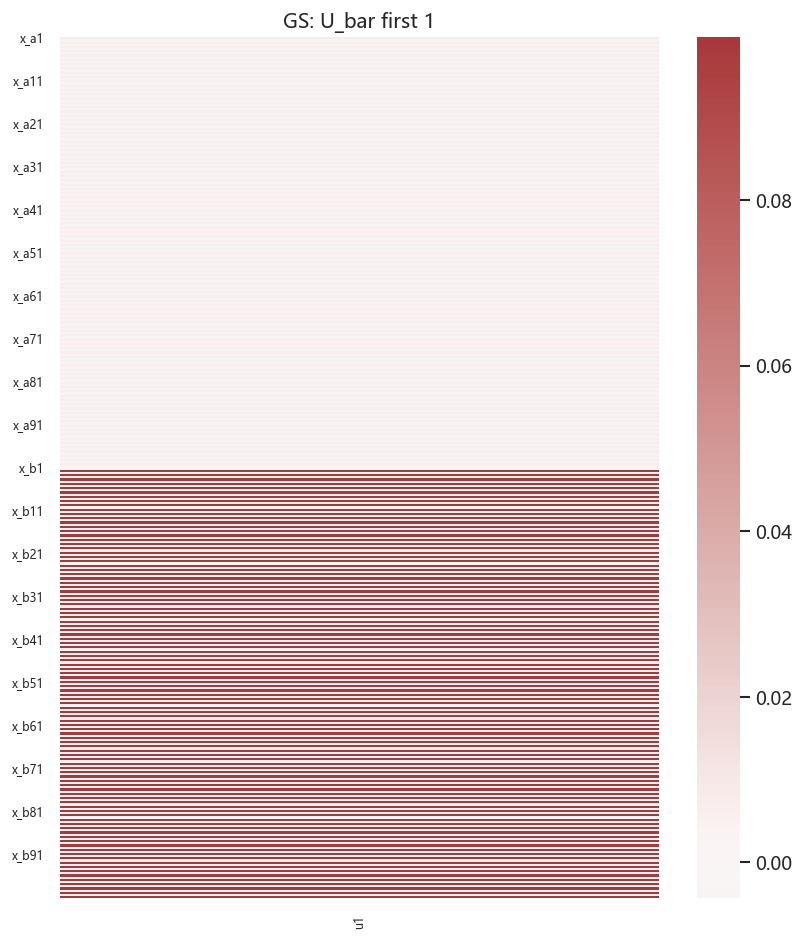

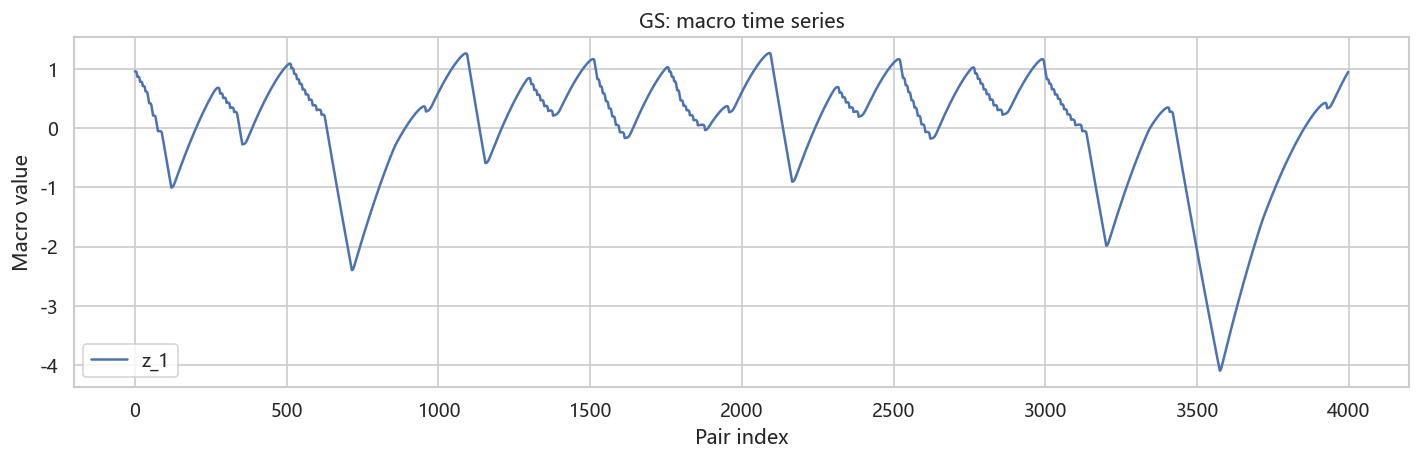

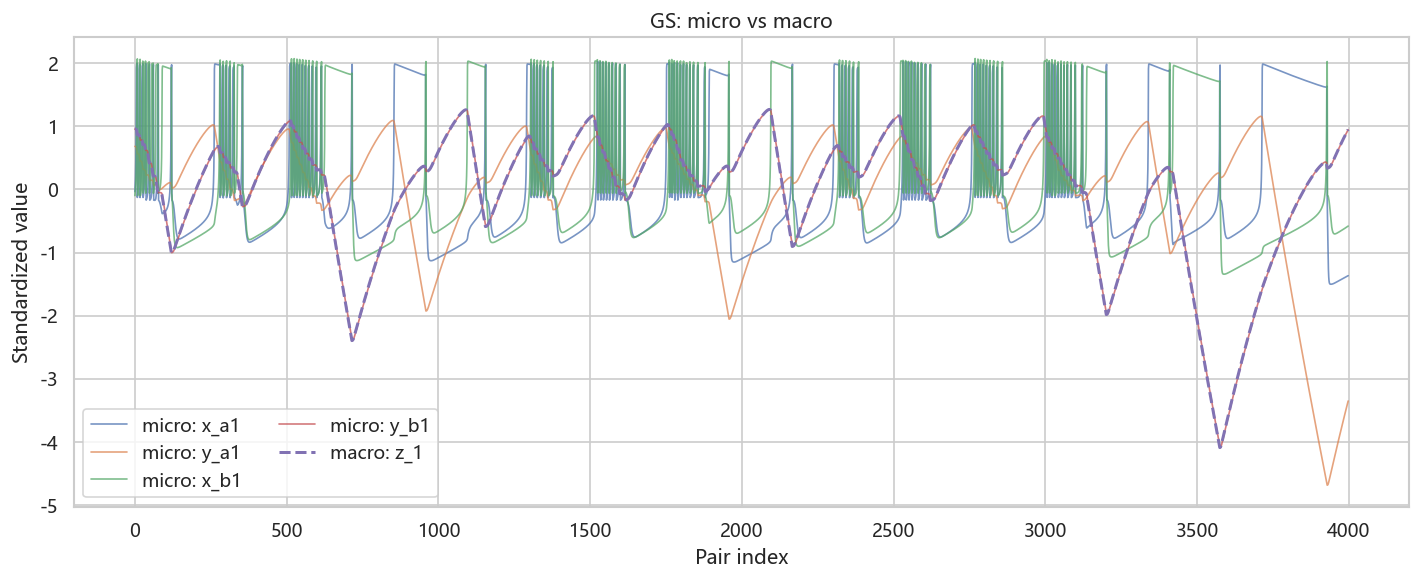

In [31]:

plot_matrix_heatmap(U_bar_GS[:, :selected_r_GS], f'GS: U_bar first {selected_r_GS}', row_labels=raw_names_GS, col_labels=[f'u{i+1}' for i in range(selected_r_GS)], figsize=(7, 8), label_step=config['heatmap_label_step'])

macro_GS = build_macro_from_kbar(
    U=U_bar_GS,
    S=S_bar_GS,
    Vt=Vt_bar_GS,
    C00_inv_sqrt=C00_inv_sqrt_GS,
    X=X_pairs_GS,
    r=selected_r_GS,
    feature_names=raw_names_GS,
    Y=Y_pairs_GS,
    C11_inv_sqrt=C11_inv_sqrt_GS,
    center=False,
)

z_current_GS = macro_GS['z_current']
macro_names_GS = [f'z_{i+1}' for i in range(selected_r_GS)]
plt.figure(figsize=(12, 4))
for i in range(selected_r_GS):
    plt.plot(z_current_GS[:, i], linewidth=1.5, label=macro_names_GS[i])
plt.title('GS: macro time series')
plt.xlabel('Pair index')
plt.ylabel('Macro value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for idx in selected_micro_indices_GS:
    plt.plot(standardize_for_plot(X_pairs_GS[:, idx]), linewidth=1.0, alpha=0.75, label=f'micro: {raw_names_GS[idx]}')
for i in range(selected_r_GS):
    plt.plot(standardize_for_plot(z_current_GS[:, i]), linewidth=1.8, linestyle='--', label=f'macro: {macro_names_GS[i]}')
plt.title('GS: micro vs macro')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Block 14. 统一摘要输出

整理该状态的关键指标，并保存为最终汇总比较所需的结果字典。

In [32]:

summary_dict_GS = {
    'experiment': {
        'name': config['experiment_name'],
        'state': state_key_GS,
        'label': state_cfg_GS['label'],
        'observable_mode': config['observable_mode'],
    },
    'scores': {
        'sync_state': sync_metrics_GS.get('sync_state'),
        'R_a': sync_metrics_GS.get('R_a'),
        'R_b': sync_metrics_GS.get('R_b'),
        'R_t': sync_metrics_GS.get('R_t'),
        'R_delta': sync_metrics_GS.get('R_delta'),
        'G_alpha_K': metrics_GS['G_alpha_K'],
        'EC': EC_GS,
        'selected_r': selected_r_GS,
        'delta_g_selected_r': delta_g_by_r_GS[selected_r_GS],
    },
}
print_summary(summary_dict_GS)

state_result_GS = {
    'state': state_key_GS,
    'label': state_cfg_GS['label'],
    'sync_metrics': sync_metrics_GS,
    'metrics': {
        'G_alpha_K': metrics_GS['G_alpha_K'],
        'EC': EC_GS,
        'selected_r': selected_r_GS,
        'delta_g_selected_r': delta_g_by_r_GS[selected_r_GS],
        'effective_rank': metrics_GS['effective_rank'],
    },
    'singular_values': S_bar_GS,
    'singular_values_raw': S_raw_GS,
    'ec_spectrum': diff_GS,
    'summary': summary_dict_GS,
}


Summary

[experiment]
           item                            value
           name                     exp_map_0321
          state                               GS
          label Generalized Synchronization (GS)
observable_mode                         identity

[scores]
              item                                 value
        sync_state Generalized Synchronization 广义同步 (GS)
               R_a                                   0.0
               R_b                                   0.0
               R_t                              0.451786
           R_delta                              0.903573
         G_alpha_K                            -65.673864
                EC                              6.577263
        selected_r                                     1
delta_g_selected_r                             17.150834


## Part 4. 奇美拉态 Q

本部分采用 `examp_map_Q.ipynb` 中当前的奇美拉态参数，并沿用与 CS 相同的块结构。

### Block 3. 数据生成：Q 状态

生成奇美拉态下的 Rulkov 数据，并先检查同步指标与状态标签。

State key: Q
State label: Chimera State (Q)
Raw data shape: (2000, 400)
Sync metrics: {'R_a': np.float64(1.8119165022534301e-16), 'R_b': np.float64(1.4183501858139902), 'R_t': np.float64(1.0556433747215015), 'R_delta': np.float64(0.4904926748747356), 'sync_state': 'Chimera State 奇美拉态(Q)'}


,state,sync_state,R_a,R_b,R_t,R_delta
0,Q,Chimera State 奇美拉态(Q),1.811917e-16,1.41835,1.055643,0.490493


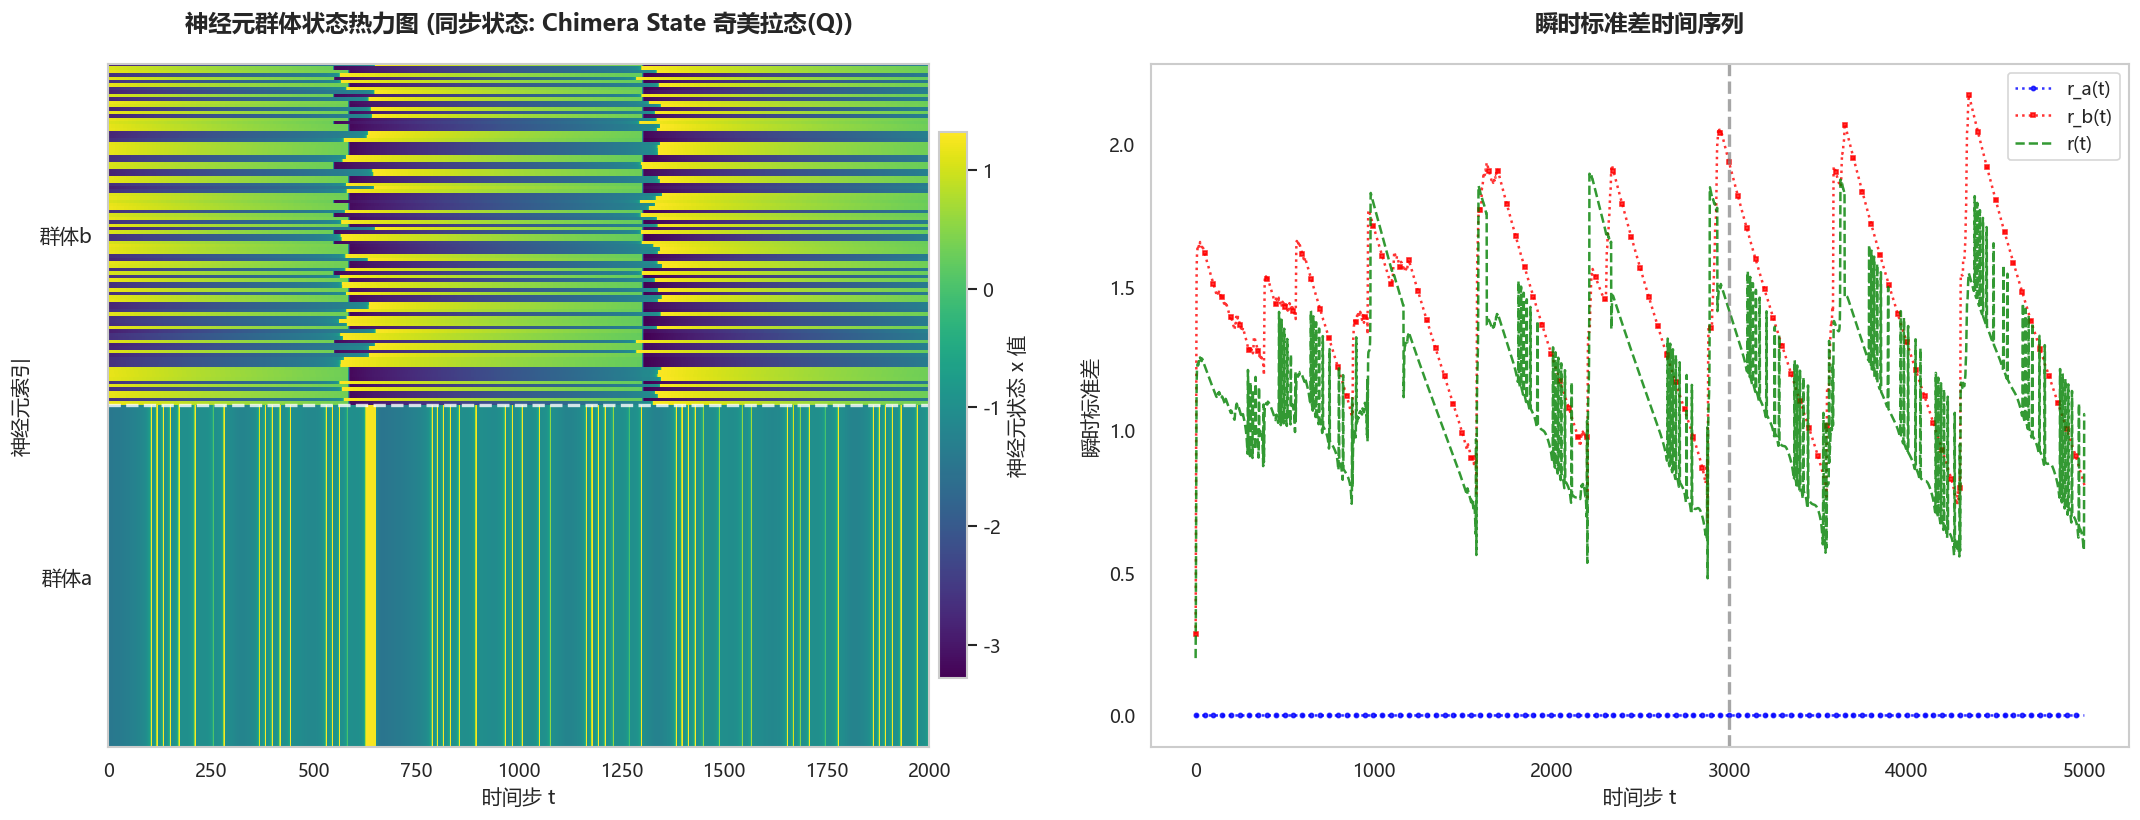

In [33]:

state_key_Q = 'Q'
state_cfg_Q = config['states'][state_key_Q]

state_args_Q = {k: v for k, v in state_cfg_Q.items() if k != 'label'}

data_Q = generate_two_population_neuron_data(**state_args_Q)
raw_pack_Q = extract_state_matrix_from_rulkov_data(
    data_Q,
    include_x=config['include_x'],
    include_y=config['include_y'],
    use_transient=config['use_transient'],
)

x_data_raw_Q = raw_pack_Q['x_data_raw']
state_names_raw_Q = raw_pack_Q['state_names']
t_data_raw_Q = raw_pack_Q['time_data']
sync_metrics_Q = raw_pack_Q['sync_metrics']
selected_micro_indices_Q = [idx for idx in config['selected_micro_indices'] if idx < x_data_raw_Q.shape[1]]

print('State key:', state_key_Q)
print('State label:', state_cfg_Q['label'])
print('Raw data shape:', x_data_raw_Q.shape)
print('Sync metrics:', sync_metrics_Q)
display(pd.DataFrame([{
    'state': state_key_Q,
    'sync_state': sync_metrics_Q.get('sync_state'),
    'R_a': sync_metrics_Q.get('R_a'),
    'R_b': sync_metrics_Q.get('R_b'),
    'R_t': sync_metrics_Q.get('R_t'),
    'R_delta': sync_metrics_Q.get('R_delta'),
}]))
plot_neuron_analysis_combo(data_Q, figsize=(18, 7))


### Block 4-7. 数据整理、lift 与白化 Koopman 构造

以下步骤与 CS 相同，这里简写说明，只保留结果输出与必要图表。

Prepared data shape: (2000, 400)
tau = 1
Pair count: 1999
cond(C00): 3.123582511541683e+36
cond(C11): 6.458864785387682e+35
sigma_max(K_bar): 1.0000003511149165


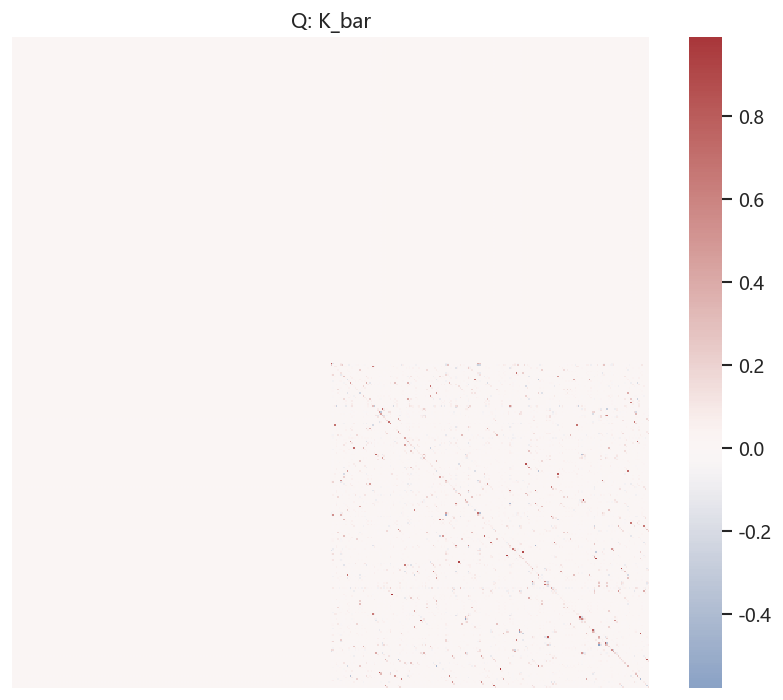

In [46]:

x_data_fit_Q = x_data_raw_Q[config['burn_in_steps']::config['sample_stride']].copy()
t_data_fit_Q = t_data_raw_Q[config['burn_in_steps']::config['sample_stride']].copy()
state_names_fit_Q = state_names_raw_Q.copy()
dt_fit_Q = 1 * config['sample_stride']
tau_Q = config['lag_steps'] * dt_fit_Q

library_Q = ps.IdentityLibrary()
library_Q.fit(x_data_fit_Q)
x_data_lift_Q = library_Q.transform(x_data_fit_Q)
raw_names_Q = library_Q.get_feature_names(input_features=state_names_fit_Q)
x_data_lift_Q = x_data_lift_Q - np.mean(x_data_lift_Q, axis=0, keepdims=True)

transition_stats_Q = compute_transition_covariances(
    [x_data_lift_Q],
    library=None,
    weights='uniform',
    lag_steps=config['lag_steps'],
)
C00_Q = transition_stats_Q['C00']
C01_Q = transition_stats_Q['C01']
C11_Q = transition_stats_Q['C11']
X_pairs_Q = transition_stats_Q['X']
Y_pairs_Q = transition_stats_Q['Y']

koop_fit_Q = fit_data_koopman_operator(
    [x_data_lift_Q],
    library=None,
    weights='uniform',
    eps=config['eps'],
    ridge=config['ridge'],
    lag_steps=config['lag_steps'],
)
K_raw_Q = koop_fit_Q['A']
K_bar_Q = koop_fit_Q['K_bar']
C00_inv_sqrt_Q = koop_fit_Q['C00_inv_sqrt']
C11_inv_sqrt_Q = koop_fit_Q['C11_inv_sqrt']

print('Prepared data shape:', x_data_fit_Q.shape)
print('tau =', tau_Q)
print('Pair count:', X_pairs_Q.shape[0])
print('cond(C00):', np.linalg.cond(C00_Q))
print('cond(C11):', np.linalg.cond(C11_Q))
print('sigma_max(K_bar):', np.linalg.svd(K_bar_Q, compute_uv=False)[0])
plot_matrix_heatmap(K_bar_Q, 'Q: K_bar', figsize=(7, 6), label_step=5)


### Block 8-10. 奇异值谱、EC 与宏观效率增益

以下指标与 CS 的定义完全相同，这里只展示该状态的谱结果和关键单值指标。

Top 10 singular values of K_bar: [1.00000035 1.00000023 1.00000019 1.00000011 1.00000008 1.00000007
 1.00000004 1.00000004 1.00000002 1.00000002]
Top 10 singular values of K_raw: [14216.04924814  3696.75952454  2901.49242482  2477.10460381
   795.0160341    659.69128882   623.7189733    598.2492908
   589.72293866   487.10870415]
G_alpha^K: -338.2086384360241
EC: 8.241423251241505
Selected r: 3
Macro efficiency gain CE: 14.113144265496901


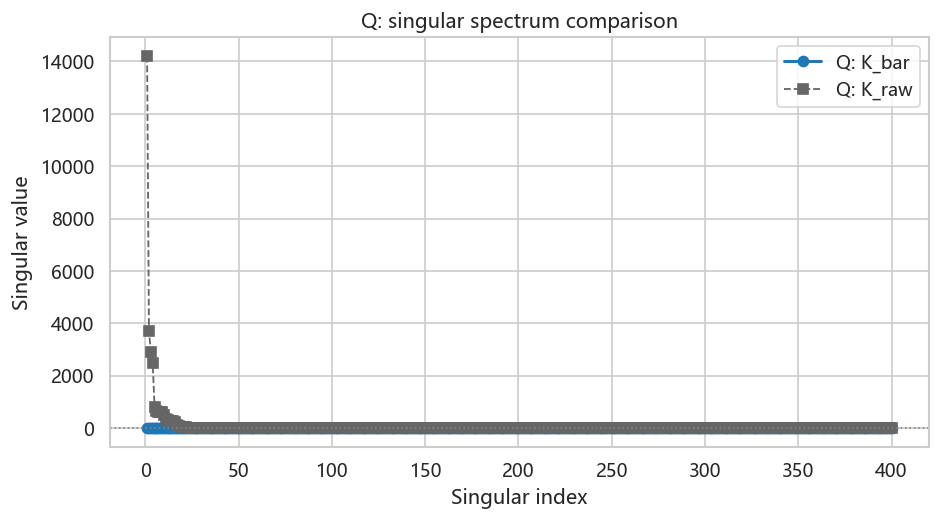

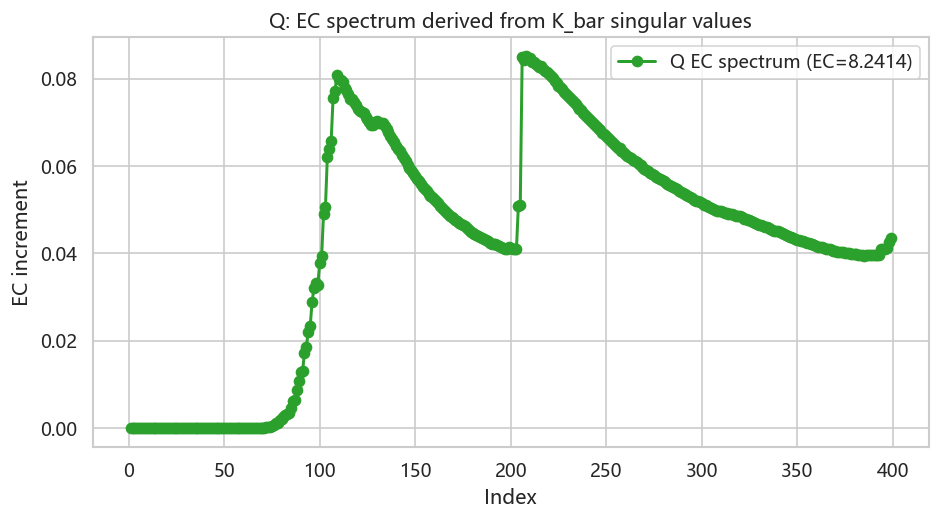

In [35]:

U_raw_Q, S_raw_Q, Vt_raw_Q = np.linalg.svd(K_raw_Q, full_matrices=False)
metrics_Q = analyze_kbar_metrics(K_bar_Q, alpha=config['alpha'], eps=config['eps'])
U_bar_Q = metrics_Q['U']
S_bar_Q = metrics_Q['S']
Vt_bar_Q = metrics_Q['Vt']
diff_Q = get_positive_contributions(S_bar_Q)
EC_Q = compute_entropy(diff_Q)

rho2_Q = np.clip(S_bar_Q**2, config['eps'], 1.0 - config['eps'])
g_i_Q = (0.5 - config['alpha'] / 4.0) * np.log(rho2_Q / (1.0 - rho2_Q)) + (config['alpha'] / 4.0) * np.log(1.0 / (1.0 - rho2_Q))
rank_candidates_Q = [r for r in config['rank_candidates'] if 1 <= r <= len(g_i_Q)]
delta_g_by_r_Q = {r: float(np.mean(g_i_Q[:r]) - np.mean(g_i_Q)) for r in rank_candidates_Q}
selected_r_Q = int(config['rank']) if config['rank'] is not None else int(max(delta_g_by_r_Q, key=delta_g_by_r_Q.get))

print('Top 10 singular values of K_bar:', S_bar_Q[:10])
print('Top 10 singular values of K_raw:', S_raw_Q[:10])
print('G_alpha^K:', metrics_Q['G_alpha_K'])
print('EC:', EC_Q)
print('Selected r:', selected_r_Q)
print('Macro efficiency gain CE:', delta_g_by_r_Q[selected_r_Q])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(S_bar_Q) + 1), S_bar_Q, marker='o', linewidth=1.8, label='Q: K_bar', color='tab:blue')
ax.plot(np.arange(1, len(S_raw_Q) + 1), S_raw_Q, marker='s', linewidth=1.1, linestyle='--', label='Q: K_raw', color='0.4')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('Q: singular spectrum comparison')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(diff_Q) + 1), diff_Q, marker='o', linewidth=1.8, color='tab:green', label=f'Q EC spectrum (EC={EC_Q:.4f})')
ax.set_xlabel('Index')
ax.set_ylabel('EC increment')
ax.set_title('Q: EC spectrum derived from K_bar singular values')
ax.legend()
plt.tight_layout()
plt.show()


### Block 11-13. 左奇异向量、粗粒化函数与宏微观对比

以下部分延续 CS 的展示方式，观察该状态下宏观变量的构成与宏微观关系。

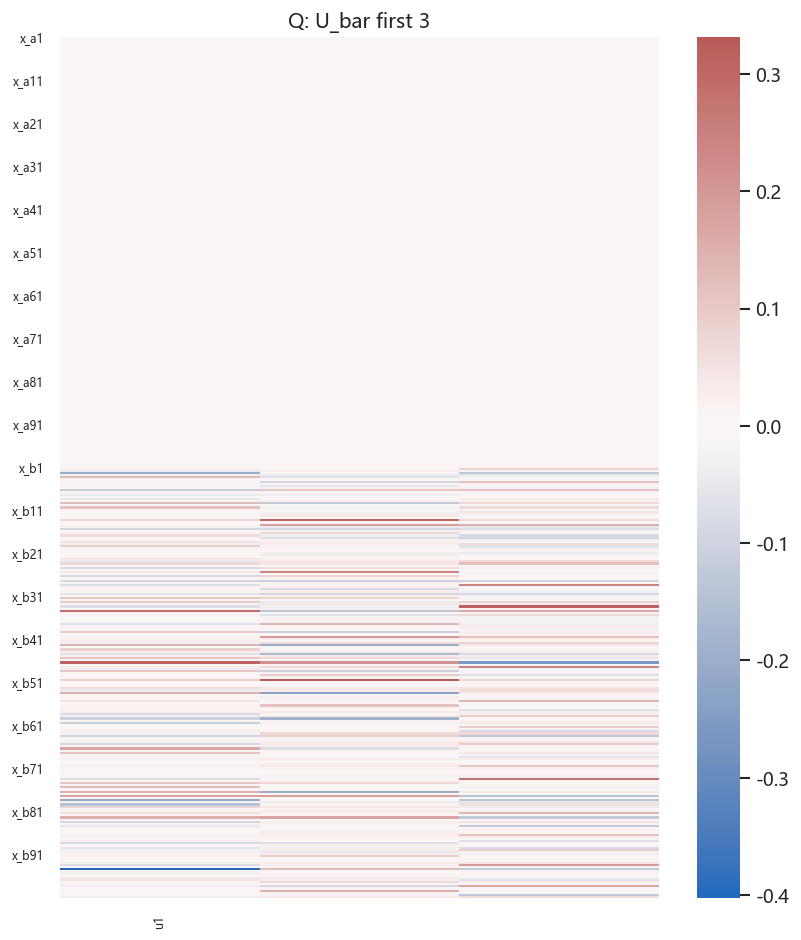

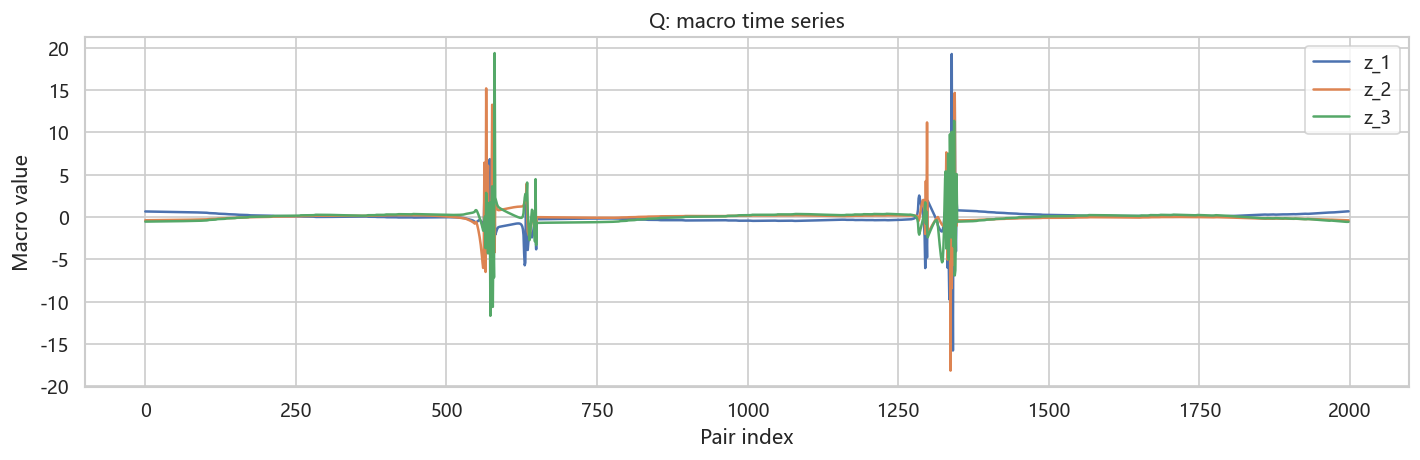

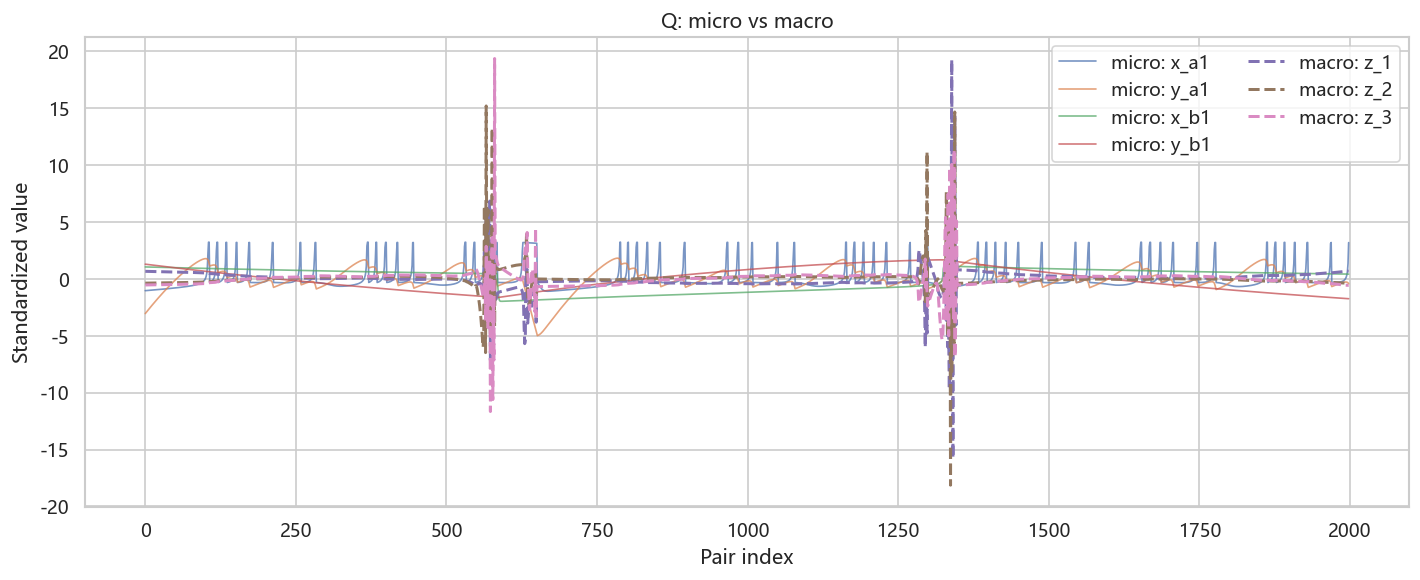

In [36]:

plot_matrix_heatmap(U_bar_Q[:, :selected_r_Q], f'Q: U_bar first {selected_r_Q}', row_labels=raw_names_Q, col_labels=[f'u{i+1}' for i in range(selected_r_Q)], figsize=(7, 8), label_step=config['heatmap_label_step'])

macro_Q = build_macro_from_kbar(
    U=U_bar_Q,
    S=S_bar_Q,
    Vt=Vt_bar_Q,
    C00_inv_sqrt=C00_inv_sqrt_Q,
    X=X_pairs_Q,
    r=selected_r_Q,
    feature_names=raw_names_Q,
    Y=Y_pairs_Q,
    C11_inv_sqrt=C11_inv_sqrt_Q,
    center=False,
)

z_current_Q = macro_Q['z_current']
macro_names_Q = [f'z_{i+1}' for i in range(selected_r_Q)]
plt.figure(figsize=(12, 4))
for i in range(selected_r_Q):
    plt.plot(z_current_Q[:, i], linewidth=1.5, label=macro_names_Q[i])
plt.title('Q: macro time series')
plt.xlabel('Pair index')
plt.ylabel('Macro value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for idx in selected_micro_indices_Q:
    plt.plot(standardize_for_plot(X_pairs_Q[:, idx]), linewidth=1.0, alpha=0.75, label=f'micro: {raw_names_Q[idx]}')
for i in range(selected_r_Q):
    plt.plot(standardize_for_plot(z_current_Q[:, i]), linewidth=1.8, linestyle='--', label=f'macro: {macro_names_Q[i]}')
plt.title('Q: micro vs macro')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Block 14. 统一摘要输出

整理该状态的关键指标，并保存为最终汇总比较所需的结果字典。

In [37]:

summary_dict_Q = {
    'experiment': {
        'name': config['experiment_name'],
        'state': state_key_Q,
        'label': state_cfg_Q['label'],
        'observable_mode': config['observable_mode'],
    },
    'scores': {
        'sync_state': sync_metrics_Q.get('sync_state'),
        'R_a': sync_metrics_Q.get('R_a'),
        'R_b': sync_metrics_Q.get('R_b'),
        'R_t': sync_metrics_Q.get('R_t'),
        'R_delta': sync_metrics_Q.get('R_delta'),
        'G_alpha_K': metrics_Q['G_alpha_K'],
        'EC': EC_Q,
        'selected_r': selected_r_Q,
        'delta_g_selected_r': delta_g_by_r_Q[selected_r_Q],
    },
}
print_summary(summary_dict_Q)

state_result_Q = {
    'state': state_key_Q,
    'label': state_cfg_Q['label'],
    'sync_metrics': sync_metrics_Q,
    'metrics': {
        'G_alpha_K': metrics_Q['G_alpha_K'],
        'EC': EC_Q,
        'selected_r': selected_r_Q,
        'delta_g_selected_r': delta_g_by_r_Q[selected_r_Q],
        'effective_rank': metrics_Q['effective_rank'],
    },
    'singular_values': S_bar_Q,
    'singular_values_raw': S_raw_Q,
    'ec_spectrum': diff_Q,
    'summary': summary_dict_Q,
}


Summary

[experiment]
           item             value
           name      exp_map_0321
          state                 Q
          label Chimera State (Q)
observable_mode          identity

[scores]
              item                 value
        sync_state Chimera State 奇美拉态(Q)
               R_a                   0.0
               R_b               1.41835
               R_t              1.055643
           R_delta              0.490493
         G_alpha_K           -338.208638
                EC              8.241423
        selected_r                     3
delta_g_selected_r             14.113144


## Part 5. 去同步化 D

分析流程与 CS 相同，这里重点保留状态确认、谱结果与关键指标。

### Block 3. 数据生成：D 状态

生成去同步化情形下的 Rulkov 数据，并先检查同步指标与状态标签。

State key: D
State label: Desynchronization (D)
Raw data shape: (2000, 400)
Sync metrics: {'R_a': np.float64(1.3419590739993188), 'R_b': np.float64(1.3470845581547528), 'R_t': np.float64(1.3512867678607943), 'R_delta': np.float64(0.16761290708592816), 'sync_state': 'Desynchronization 去同步化(D)'}


,state,sync_state,R_a,R_b,R_t,R_delta
0,D,Desynchronization 去同步化(D),1.341959,1.347085,1.351287,0.167613


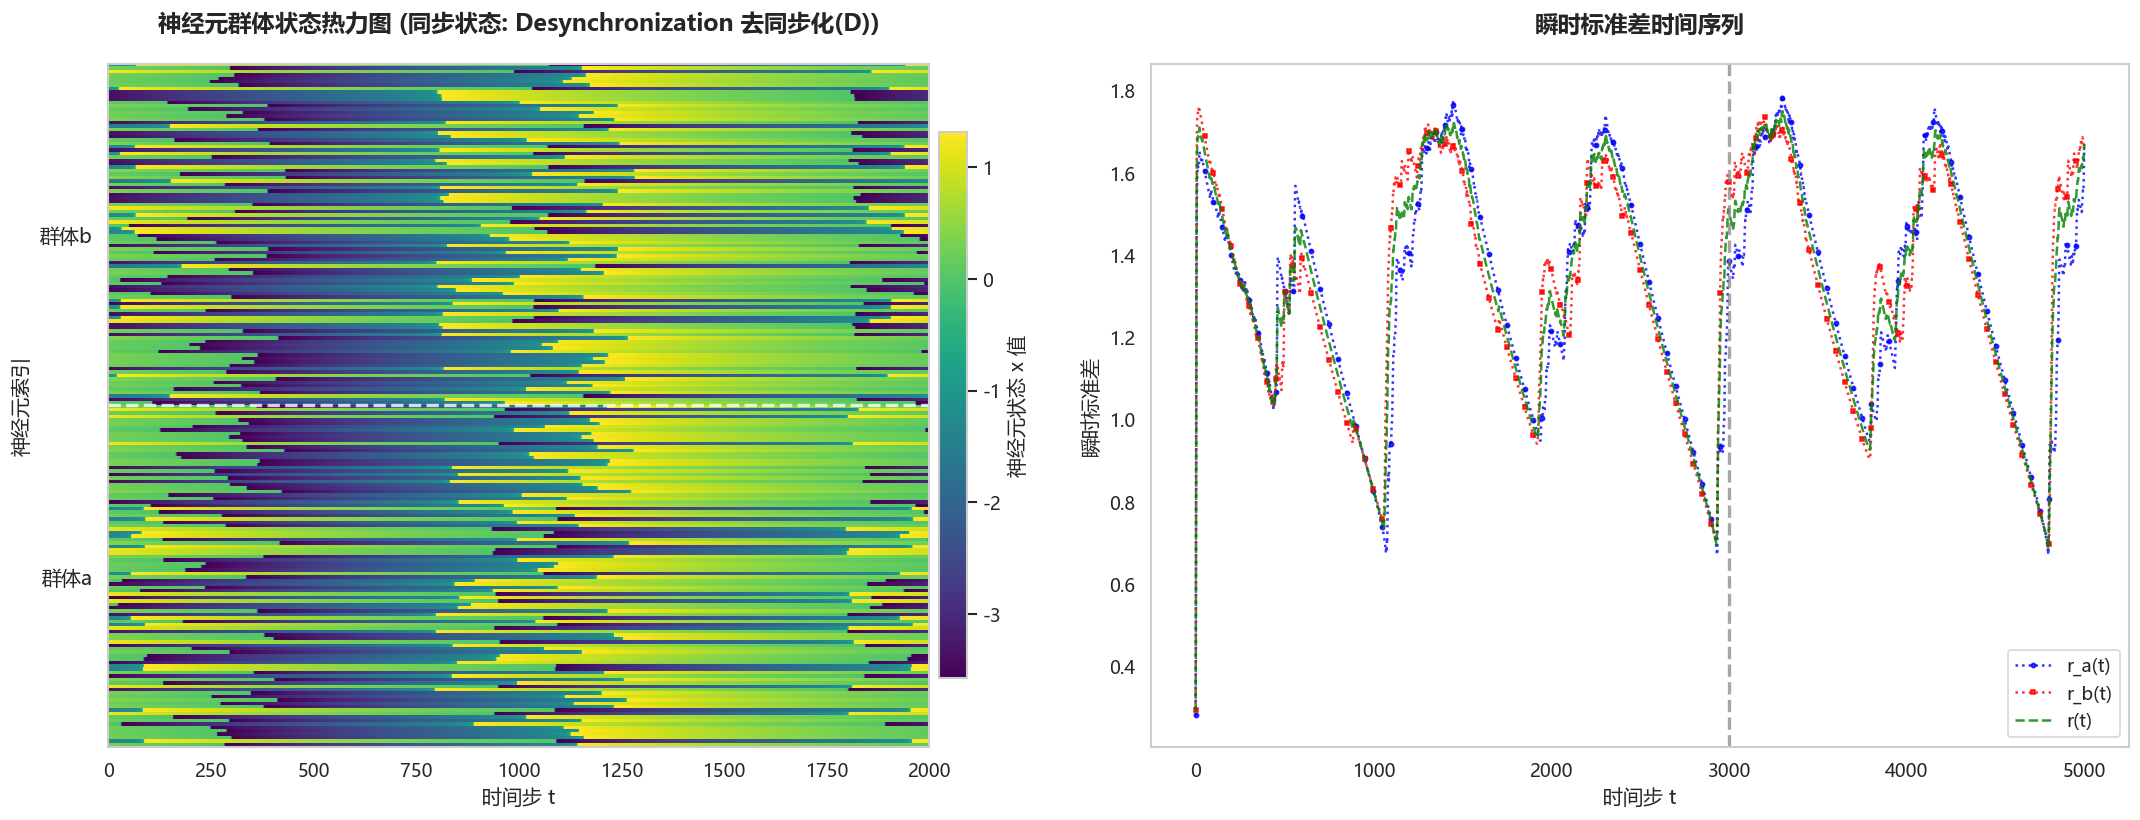

In [38]:

state_key_D = 'D'
state_cfg_D = config['states'][state_key_D]

state_args_D = {k: v for k, v in state_cfg_D.items() if k != 'label'}

data_D = generate_two_population_neuron_data(**state_args_D)
raw_pack_D = extract_state_matrix_from_rulkov_data(
    data_D,
    include_x=config['include_x'],
    include_y=config['include_y'],
    use_transient=config['use_transient'],
)

x_data_raw_D = raw_pack_D['x_data_raw']
state_names_raw_D = raw_pack_D['state_names']
t_data_raw_D = raw_pack_D['time_data']
sync_metrics_D = raw_pack_D['sync_metrics']
selected_micro_indices_D = [idx for idx in config['selected_micro_indices'] if idx < x_data_raw_D.shape[1]]

print('State key:', state_key_D)
print('State label:', state_cfg_D['label'])
print('Raw data shape:', x_data_raw_D.shape)
print('Sync metrics:', sync_metrics_D)
display(pd.DataFrame([{
    'state': state_key_D,
    'sync_state': sync_metrics_D.get('sync_state'),
    'R_a': sync_metrics_D.get('R_a'),
    'R_b': sync_metrics_D.get('R_b'),
    'R_t': sync_metrics_D.get('R_t'),
    'R_delta': sync_metrics_D.get('R_delta'),
}]))
plot_neuron_analysis_combo(data_D, figsize=(18, 7))


### Block 4-7. 数据整理、lift 与白化 Koopman 构造

以下步骤与 CS 相同，这里简写说明，只保留结果输出与必要图表。

Prepared data shape: (2000, 400)
tau = 1
Pair count: 1999
cond(C00): 2.5019588600193797e+18
cond(C11): 2.15848137441189e+18
sigma_max(K_bar): 1.0000426694412126


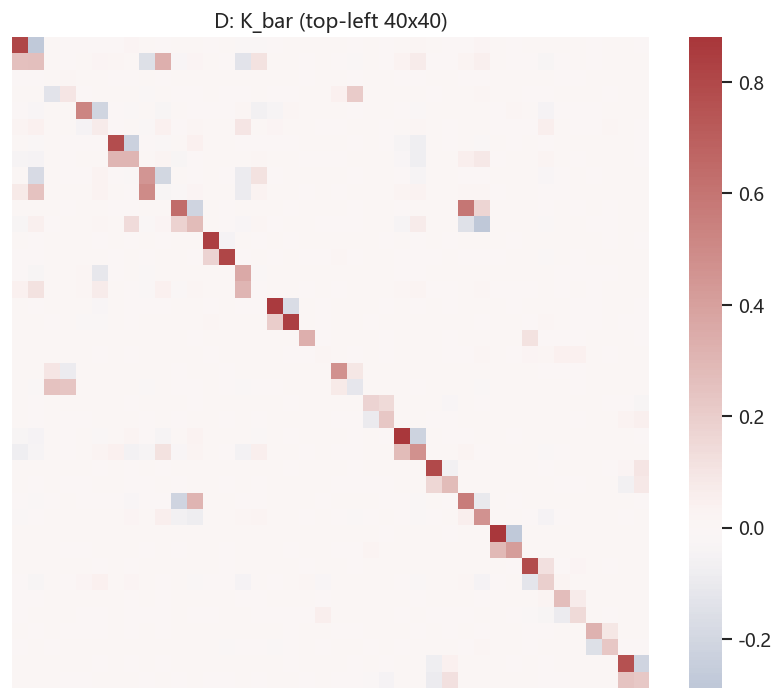

In [39]:

x_data_fit_D = x_data_raw_D[config['burn_in_steps']::config['sample_stride']].copy()
t_data_fit_D = t_data_raw_D[config['burn_in_steps']::config['sample_stride']].copy()
state_names_fit_D = state_names_raw_D.copy()
dt_fit_D = 1 * config['sample_stride']
tau_D = config['lag_steps'] * dt_fit_D

library_D = ps.IdentityLibrary()
library_D.fit(x_data_fit_D)
x_data_lift_D = library_D.transform(x_data_fit_D)
raw_names_D = library_D.get_feature_names(input_features=state_names_fit_D)
x_data_lift_D = x_data_lift_D - np.mean(x_data_lift_D, axis=0, keepdims=True)

transition_stats_D = compute_transition_covariances(
    [x_data_lift_D],
    library=None,
    weights='uniform',
    lag_steps=config['lag_steps'],
)
C00_D = transition_stats_D['C00']
C01_D = transition_stats_D['C01']
C11_D = transition_stats_D['C11']
X_pairs_D = transition_stats_D['X']
Y_pairs_D = transition_stats_D['Y']

koop_fit_D = fit_data_koopman_operator(
    [x_data_lift_D],
    library=None,
    weights='uniform',
    eps=config['eps'],
    ridge=config['ridge'],
    lag_steps=config['lag_steps'],
)
K_raw_D = koop_fit_D['A']
K_bar_D = koop_fit_D['K_bar']
C00_inv_sqrt_D = koop_fit_D['C00_inv_sqrt']
C11_inv_sqrt_D = koop_fit_D['C11_inv_sqrt']

print('Prepared data shape:', x_data_fit_D.shape)
print('tau =', tau_D)
print('Pair count:', X_pairs_D.shape[0])
print('cond(C00):', np.linalg.cond(C00_D))
print('cond(C11):', np.linalg.cond(C11_D))
print('sigma_max(K_bar):', np.linalg.svd(K_bar_D, compute_uv=False)[0])
plot_matrix_heatmap(K_bar_D[:40, :40], 'D: K_bar (top-left 40x40)', figsize=(7, 6), label_step=5)


### Block 8-10. 奇异值谱、EC 与宏观效率增益

以下指标与 CS 的定义完全相同，这里只展示该状态的谱结果和关键单值指标。

Top 10 singular values of K_bar: [1.00004267 1.00002027 1.00001406 1.00000463 1.00000373 1.00000121
 1.00000061 1.00000033 1.00000028 1.00000024]
Top 10 singular values of K_raw: [1807.20053394 1060.31262903 1035.35468365  967.9773953   953.92489082
  946.20033676  918.45265306  906.80181426  897.05191616  889.01949971]
G_alpha^K: 645.7969896295707
EC: 6.632991315884263
Selected r: 3
Macro efficiency gain CE: 7.9504378345113675


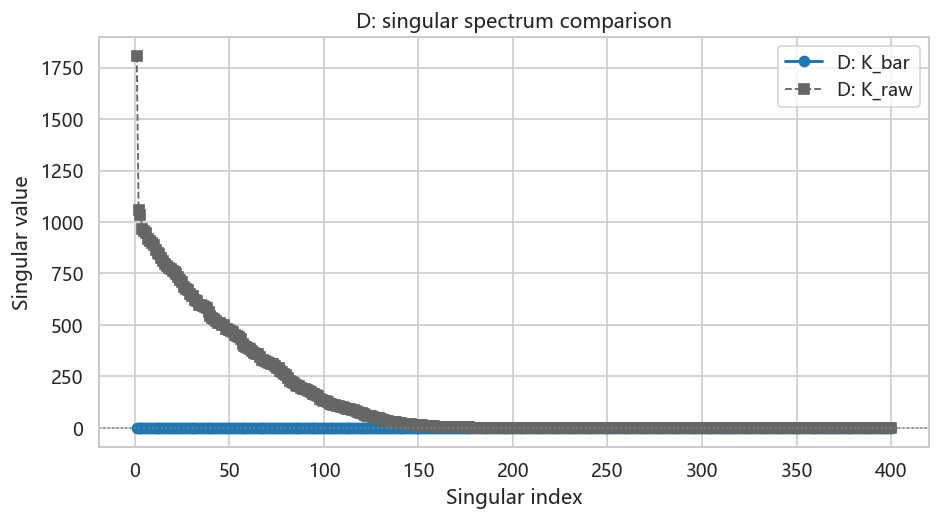

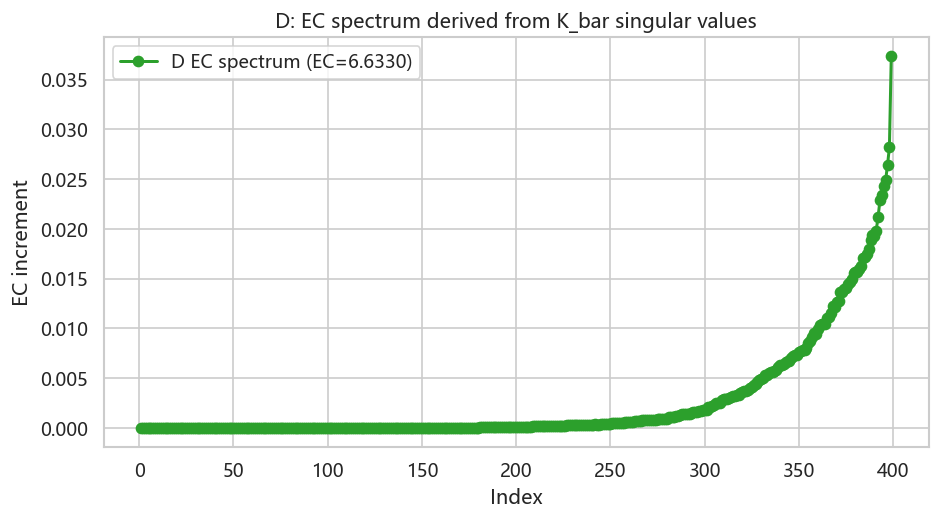

In [40]:

U_raw_D, S_raw_D, Vt_raw_D = np.linalg.svd(K_raw_D, full_matrices=False)
metrics_D = analyze_kbar_metrics(K_bar_D, alpha=config['alpha'], eps=config['eps'])
U_bar_D = metrics_D['U']
S_bar_D = metrics_D['S']
Vt_bar_D = metrics_D['Vt']
diff_D = get_positive_contributions(S_bar_D)
EC_D = compute_entropy(diff_D)

rho2_D = np.clip(S_bar_D**2, config['eps'], 1.0 - config['eps'])
g_i_D = (0.5 - config['alpha'] / 4.0) * np.log(rho2_D / (1.0 - rho2_D)) + (config['alpha'] / 4.0) * np.log(1.0 / (1.0 - rho2_D))
rank_candidates_D = [r for r in config['rank_candidates'] if 1 <= r <= len(g_i_D)]
delta_g_by_r_D = {r: float(np.mean(g_i_D[:r]) - np.mean(g_i_D)) for r in rank_candidates_D}
selected_r_D = int(config['rank']) if config['rank'] is not None else int(max(delta_g_by_r_D, key=delta_g_by_r_D.get))

print('Top 10 singular values of K_bar:', S_bar_D[:10])
print('Top 10 singular values of K_raw:', S_raw_D[:10])
print('G_alpha^K:', metrics_D['G_alpha_K'])
print('EC:', EC_D)
print('Selected r:', selected_r_D)
print('Macro efficiency gain CE:', delta_g_by_r_D[selected_r_D])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(S_bar_D) + 1), S_bar_D, marker='o', linewidth=1.8, label='D: K_bar', color='tab:blue')
ax.plot(np.arange(1, len(S_raw_D) + 1), S_raw_D, marker='s', linewidth=1.1, linestyle='--', label='D: K_raw', color='0.4')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('D: singular spectrum comparison')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(diff_D) + 1), diff_D, marker='o', linewidth=1.8, color='tab:green', label=f'D EC spectrum (EC={EC_D:.4f})')
ax.set_xlabel('Index')
ax.set_ylabel('EC increment')
ax.set_title('D: EC spectrum derived from K_bar singular values')
ax.legend()
plt.tight_layout()
plt.show()


### Block 11-13. 左奇异向量、粗粒化函数与宏微观对比

以下部分延续 CS 的展示方式，观察该状态下宏观变量的构成与宏微观关系。

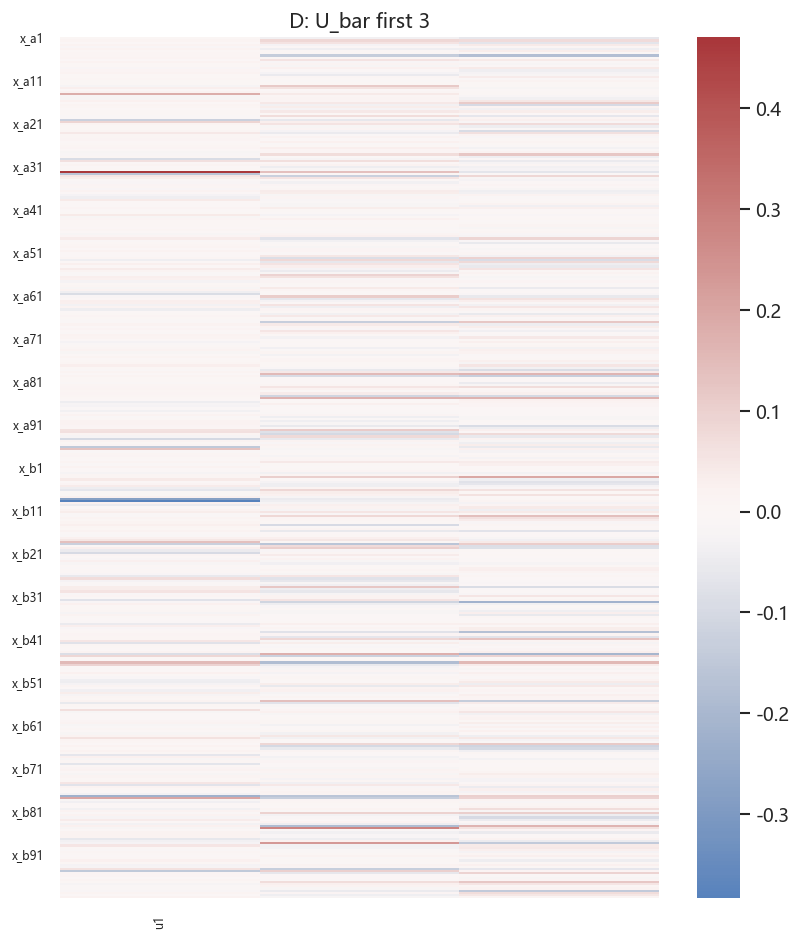

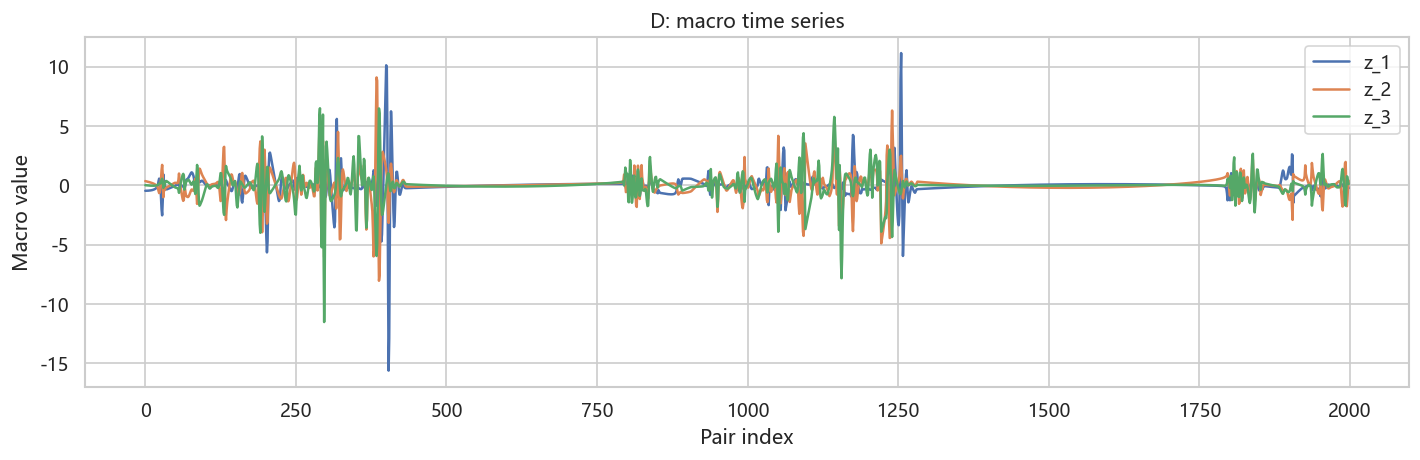

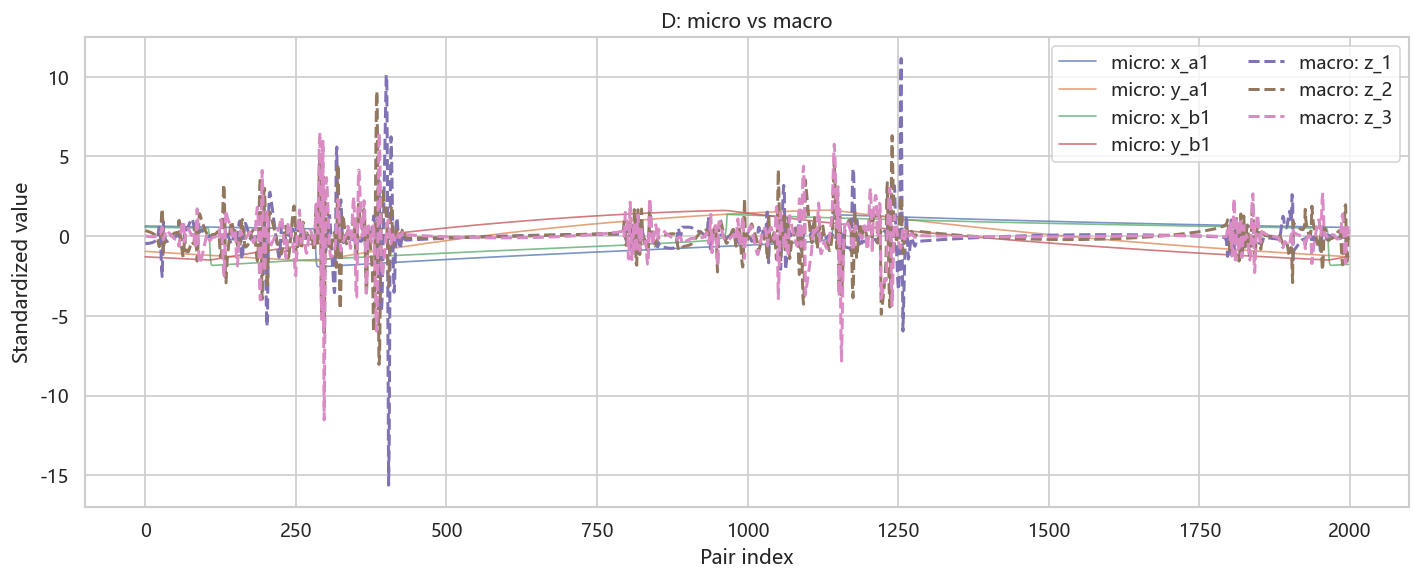

In [41]:

plot_matrix_heatmap(U_bar_D[:, :selected_r_D], f'D: U_bar first {selected_r_D}', row_labels=raw_names_D, col_labels=[f'u{i+1}' for i in range(selected_r_D)], figsize=(7, 8), label_step=config['heatmap_label_step'])

macro_D = build_macro_from_kbar(
    U=U_bar_D,
    S=S_bar_D,
    Vt=Vt_bar_D,
    C00_inv_sqrt=C00_inv_sqrt_D,
    X=X_pairs_D,
    r=selected_r_D,
    feature_names=raw_names_D,
    Y=Y_pairs_D,
    C11_inv_sqrt=C11_inv_sqrt_D,
    center=False,
)

z_current_D = macro_D['z_current']
macro_names_D = [f'z_{i+1}' for i in range(selected_r_D)]
plt.figure(figsize=(12, 4))
for i in range(selected_r_D):
    plt.plot(z_current_D[:, i], linewidth=1.5, label=macro_names_D[i])
plt.title('D: macro time series')
plt.xlabel('Pair index')
plt.ylabel('Macro value')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for idx in selected_micro_indices_D:
    plt.plot(standardize_for_plot(X_pairs_D[:, idx]), linewidth=1.0, alpha=0.75, label=f'micro: {raw_names_D[idx]}')
for i in range(selected_r_D):
    plt.plot(standardize_for_plot(z_current_D[:, i]), linewidth=1.8, linestyle='--', label=f'macro: {macro_names_D[i]}')
plt.title('D: micro vs macro')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Block 14. 统一摘要输出

整理该状态的关键指标，并保存为最终汇总比较所需的结果字典。

In [42]:

summary_dict_D = {
    'experiment': {
        'name': config['experiment_name'],
        'state': state_key_D,
        'label': state_cfg_D['label'],
        'observable_mode': config['observable_mode'],
    },
    'scores': {
        'sync_state': sync_metrics_D.get('sync_state'),
        'R_a': sync_metrics_D.get('R_a'),
        'R_b': sync_metrics_D.get('R_b'),
        'R_t': sync_metrics_D.get('R_t'),
        'R_delta': sync_metrics_D.get('R_delta'),
        'G_alpha_K': metrics_D['G_alpha_K'],
        'EC': EC_D,
        'selected_r': selected_r_D,
        'delta_g_selected_r': delta_g_by_r_D[selected_r_D],
    },
}
print_summary(summary_dict_D)

state_result_D = {
    'state': state_key_D,
    'label': state_cfg_D['label'],
    'sync_metrics': sync_metrics_D,
    'metrics': {
        'G_alpha_K': metrics_D['G_alpha_K'],
        'EC': EC_D,
        'selected_r': selected_r_D,
        'delta_g_selected_r': delta_g_by_r_D[selected_r_D],
        'effective_rank': metrics_D['effective_rank'],
    },
    'singular_values': S_bar_D,
    'singular_values_raw': S_raw_D,
    'ec_spectrum': diff_D,
    'summary': summary_dict_D,
}


Summary

[experiment]
           item                 value
           name          exp_map_0321
          state                     D
          label Desynchronization (D)
observable_mode              identity

[scores]
              item                     value
        sync_state Desynchronization 去同步化(D)
               R_a                  1.341959
               R_b                  1.347085
               R_t                  1.351287
           R_delta                  0.167613
         G_alpha_K                 645.79699
                EC                  6.632991
        selected_r                         3
delta_g_selected_r                  7.950438


## Part 6. 四种状态汇总比较

在四种状态分别完成分析后，这一部分将奇异值谱、EC 谱与关键单值指标放在一起比较。

### Block 15. 汇总表构造

使用已添加到 `tools.py` 中的 `build_map_comparison_table`，将四种状态的关键单值指标整理成统一表格。

In [43]:

state_results = {
    'CS': state_result_CS,
    'GS': state_result_GS,
    'Q': state_result_Q,
    'D': state_result_D,
}

comparison_table = build_map_comparison_table(state_results)
comparison_table_cn = comparison_table.rename(columns={
    'state': '??',
    'sync_state': '????',
    'R_a': 'R_a',
    'R_b': 'R_b',
    'R_t': 'R_t',
    'R_delta': 'R_delta',
    'G_alpha_K': '???',
    'EC': 'EC?',
    'r': 'r',
    'CE': '??????',
    'effective_rank': 'effective_rank',
    'sigma1': 'sigma1',
    'sigma2': 'sigma2',
    'sigma3': 'sigma3',
})

display(comparison_table_cn)


,??,????,R_a,R_b,R_t,R_delta,???,EC?,r,??????,effective_rank,sigma1,sigma2,sigma3
0,CS,Complete Synchronization 完全同步(CS),1.831452e-16,1.831452e-16,1.544251e-16,0.000000,-348.977573,6.375799,1,13.594119,10,1.000000,0.723006,0.000044
1,GS,Generalized Synchronization 广义同步 (GS),2.283699e-16,2.384851e-16,4.517864e-01,0.903573,-65.673864,6.577263,1,17.150834,12,1.000000,0.999999,0.933827
2,Q,Chimera State 奇美拉态(Q),1.811917e-16,1.418350e+00,1.055643e+00,0.490493,-338.208638,8.241423,3,14.113144,206,1.000000,1.000000,1.000000
3,D,Desynchronization 去同步化(D),1.341959e+00,1.347085e+00,1.351287e+00,0.167613,645.796990,6.632991,3,7.950438,400,1.000043,1.000020,1.000014


### Block 16. 四状态奇异值谱比较

将四种状态的 $\bar K$ 奇异值谱画在同一张图中，并在图例中标注各自的 CE 值。

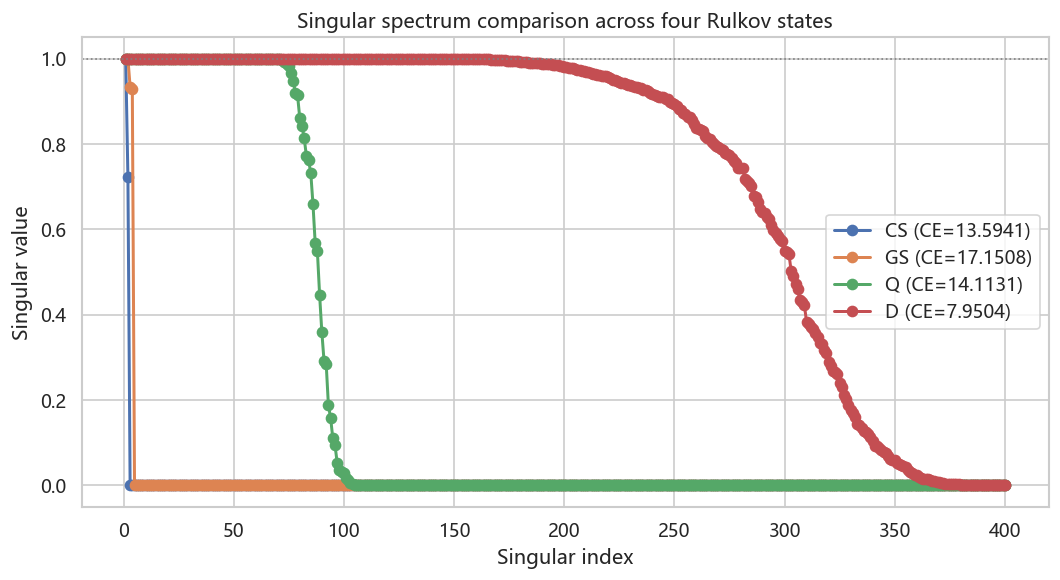

In [44]:

fig, ax = plt.subplots(figsize=(9, 5))
for state_key in state_order:
    singular_values = state_results[state_key]['singular_values']
    ce_value = state_results[state_key]['metrics']['delta_g_selected_r']
    ax.plot(
        np.arange(1, len(singular_values) + 1),
        singular_values,
        marker='o',
        linewidth=1.8,
        label=f'{state_key} (CE={ce_value:.4f})',
    )
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.set_title('Singular spectrum comparison across four Rulkov states')
ax.legend()
plt.tight_layout()
plt.show()


### Block 17. 四状态 EC 谱与关键指标比较

将四种状态的 EC 谱画在同一张图中，并进一步对宏观效率增益、主总分、EC 值和截断维数做并列比较。

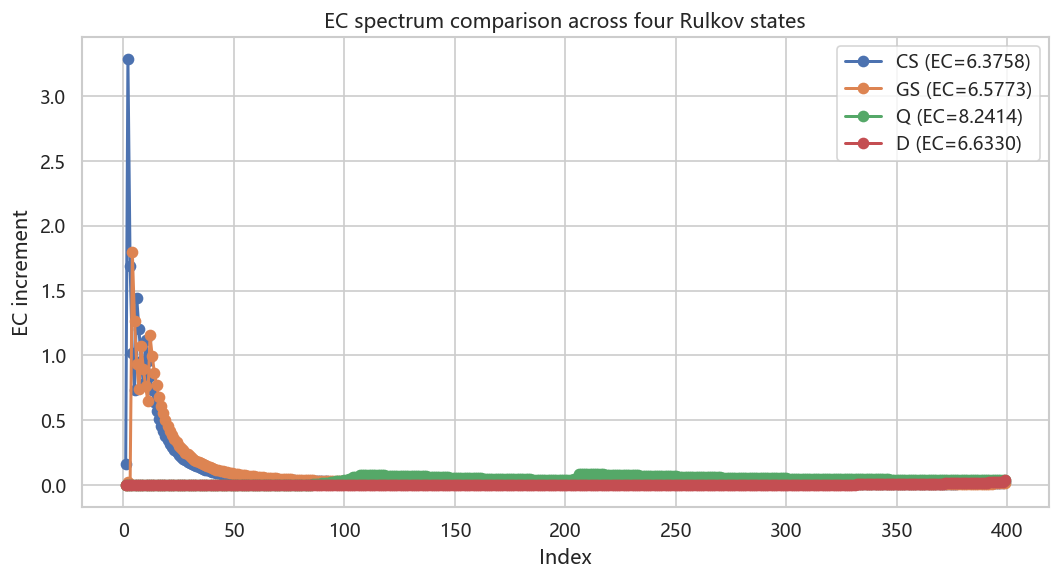

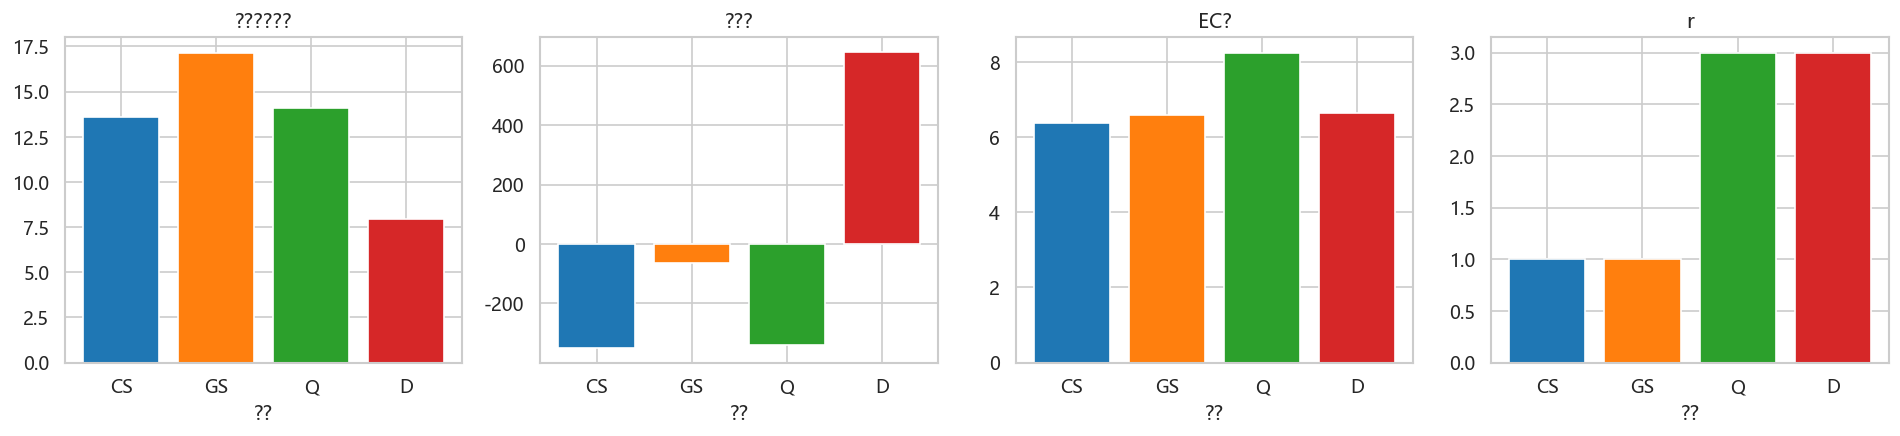

In [45]:

fig, ax = plt.subplots(figsize=(9, 5))
for state_key in state_order:
    ec_spectrum = state_results[state_key]['ec_spectrum']
    ec_value = state_results[state_key]['metrics']['EC']
    ax.plot(
        np.arange(1, len(ec_spectrum) + 1),
        ec_spectrum,
        marker='o',
        linewidth=1.8,
        label=f'{state_key} (EC={ec_value:.4f})',
    )
ax.set_xlabel('Index')
ax.set_ylabel('EC increment')
ax.set_title('EC spectrum comparison across four Rulkov states')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
metric_specs = [
    ('??????', '??????'),
    ('???', '???'),
    ('EC?', 'EC?'),
    ('r', 'r'),
]
for ax, (col, title) in zip(axes, metric_specs):
    ax.bar(comparison_table_cn['??'], comparison_table_cn[col], color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
    ax.set_title(title)
    ax.set_xlabel('??')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
